## TODO

new dataset

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator
from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset
import torch
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
class ManyToManyOverlappingDataset(Dataset):
    def __init__(self, X, y, flight_ids, indices, window_size, stride=1):
        self.X = torch.tensor(X, dtype=torch.float32) if not isinstance(X, torch.Tensor) else X
        self.y = torch.tensor(y, dtype=torch.long) if not isinstance(y, torch.Tensor) else y
        self.flight_ids = flight_ids
        self.indices = indices
        self.window_size = window_size
        self.seq_len = 2 * window_size + 1
        self.stride = stride

        self.valid_indices = []
        i = 0
        while i < len(self.X):
            fid = self.flight_ids[i]
            start = i - window_size
            end = i + window_size
            if start >= 0 and end < len(self.X):
                if all(self.flight_ids[j] == fid for j in range(start, end + 1)):
                    self.valid_indices.append(i)
                    i += stride
                    continue
            i += 1

        self.num_flights = len(np.unique(self.flight_ids))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, i):
        center_idx = self.valid_indices[i]
        start = center_idx - self.window_size
        end = center_idx + self.window_size

        window_x = self.X[start:end + 1]
        window_y = self.y[start:end + 1]
        flight_id = self.flight_ids[center_idx]
        center_index = self.indices[center_idx]

        return window_x, window_y, flight_id, center_index

    def __repr__(self):
        return (f"<ManyToManyOverlappingDataset>\n"
                f"  Total samples       : {len(self)}\n"
                f"  Input shape         : ({self.seq_len}, {self.X.shape[1]})\n"
                f"  Window size         : {self.window_size} (Total len: {self.seq_len})\n"
                f"  Stride              : {self.stride}\n"
                f"  Number of flights   : {self.num_flights}")


## ====================================================================
# 预定义 flight_id 和 filename 的映射，并且前后顺序对应着 train val test 的分配
df = pd.read_excel('问题类型记录.xlsx')

# 确保 csv_name 统一以 .csv 结尾（保险处理）
df['csv_name'] = df['csv_name'].apply(lambda x: str(x) + '.csv' if not str(x).endswith('.csv') else str(x))

# 构建映射列表
flight_files = list(zip(df['flight_id'], df['csv_name']))


# 加载数据，添加 航段记号 flight_id 和 原始索引 index
def load_data(data_folder):
    all_data = []

    for flight_id, filename in flight_files:
        file_path = os.path.join(data_folder, filename)
        
        # 检查文件是否存在，避免因缺失文件导致错误
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found, skipping...")
            continue

        print(f"Loading flight_id: {flight_id}, filename: {filename}")
        df = pd.read_csv(file_path, usecols=['status', 'VRTG'])

        # 添加 flight_id 和原始索引 index
        df['flight_id'] = flight_id
        df['index'] = df.index  # 记录在该航段中的原始索引，从 0 开始

        all_data.append(df)

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()  # 避免空数据报错


# 构造特征，rolling_window_size 为滑动窗口大小
def compute_features(df, rolling_window_size): # 小窗口，记录
    # 用于存储计算完特征的所有航段数据
    processed_data = []

    # 通过航段 ID 分组，逐个计算特征
    flight_ids = df['flight_id'].unique()  # 获取所有航段 ID
    
    # 避免跨航段
    for flight_id in flight_ids:
        flight_data = df[df['flight_id'] == flight_id].copy()  # 必须用 copy() 避免修改原 DataFrame
        
        # 一阶、二阶差分
        flight_data['VRTG_diff1'] = flight_data['VRTG'].diff().fillna(0)
        flight_data['VRTG_diff2'] = flight_data['VRTG'].diff(2).fillna(0)
        
        # rolling_window_size 大小的滑动统计特征
        flight_data['VRTG_median'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).median().fillna(0)
        flight_data['VRTG_std'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).std().fillna(0)
        
        # 当前值与滑动中位数的差值
        flight_data['VRTG_diff_median'] = flight_data['VRTG'] - flight_data['VRTG_median']
        
        # 多步差分
        flight_data['VRTG_diff_10'] = flight_data['VRTG'] - flight_data['VRTG'].shift(10).fillna(0)
        
        # 将计算完的航段数据存入列表
        processed_data.append(flight_data)

    # **拼接所有航段的数据，确保原始索引结构不丢失**
    return pd.concat(processed_data, ignore_index=True)


def compute_features_red(df, rolling_window_size): # 小窗口，记录

    flight_data = df.copy()  # 必须用 copy() 避免修改原 DataFrame

    flight_data['VRTG_diff1'] = flight_data['VRTG'].diff().fillna(0)
    flight_data['VRTG_diff2'] = flight_data['VRTG'].diff(2).fillna(0)
    
    # rolling_window_size 大小的滑动统计特征
    flight_data['VRTG_median'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).median().fillna(0)
    flight_data['VRTG_std'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).std().fillna(0)
    
    # 当前值与滑动中位数的差值
    flight_data['VRTG_diff_median'] = flight_data['VRTG'] - flight_data['VRTG_median']
    
    # 多步差分
    flight_data['VRTG_diff_10'] = flight_data['VRTG'] - flight_data['VRTG'].shift(10).fillna(0)

    return flight_data

class BiLSTMSequenceTagger(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        output: (batch, seq_len, num_classes)
        """
        lstm_out, _ = self.bilstm(x)                # -> (batch, seq_len, hidden_size*2)
        logits = self.classifier(lstm_out)          # -> (batch, seq_len, num_classes)
        return logits

def train_sequence_model(model, dataloader, optimizer, criterion, device, epochs=10):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        loader_tqdm = tqdm(dataloader, desc=f'Epoch [{epoch+1}/{epochs}]', leave=False)

        for batch_x, batch_y, _, _ in loader_tqdm:
            batch_x = batch_x.to(device)          # (batch, seq_len, feat)
            batch_y = batch_y.to(device)          # (batch, seq_len)

            optimizer.zero_grad()
            outputs = model(batch_x)              # (batch, seq_len, num_classes)
            loss = criterion(outputs.view(-1, outputs.shape[-1]), batch_y.view(-1))
            loss.backward()
            optimizer.step()

            batch_loss = loss.item()
            total_loss += batch_loss

            preds = torch.argmax(outputs, dim=2)
            correct += (preds == batch_y).sum().item()
            total += batch_y.numel()

            loader_tqdm.set_postfix(loss=batch_loss)

        acc = correct / total
        print(f"[Epoch {epoch+1}] Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1  # 记录当前轮数
        }
        torch.save(checkpoint, "best_checkpoint.pth")

def evaluate_classification(pred, true, class_names=None):
    """
    输入：
    - pred: 预测标签 (N,)
    - true: 真实标签 (N,)
    - class_names: 可选，类别名称列表
    
    输出：
    - 打印指标，绘制混淆矩阵
    """
    # 混淆矩阵
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

    # 分类报告
    print("\n📋 Classification Report:")
    print(classification_report(true, pred, target_names=class_names, digits=4))

    # 准确率
    acc = accuracy_score(true, pred)
    print(f"✅ Accuracy: {acc:.4f}")

    # 计算precision, recall, F1
    precision = precision_score(true, pred)
    recall = recall_score(true, pred)
    f1 = f1_score(true, pred)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # AUC（二分类支持）
    unique_labels = np.unique(true)
    print(f"Unique labels: {unique_labels}")
    if len(unique_labels) == 2:
        try:
            auc = roc_auc_score(true, pred)
            print(f"🔥 AUC (ROC): {auc:.4f}")

            # 绘制 ROC 曲线
            fpr, tpr, _ = roc_curve(true, pred)
            plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC Curve")
            plt.legend()
            plt.grid(True)
            plt.show()
        except Exception as e:
            print("⚠️ 无法计算 AUC，错误：", e)
    else:
        print("⚠️ AUC 仅支持二分类，当前检测到多于两个标签。")


## 1.定义训练参数

In [3]:
window_size = 100           # 前后各 window_size 个，共 2 * window_size 个数据点
stride = 20                 # 滑动步长
rolling_window_size = 96    # 滑动窗口前后共 rolling_window_size 【中位数，96,bs:256】
batch_size = 256

In [4]:
# 分为三块：
# 1 train-val1，其中 normal 样本与2共用，abnormal 样本只用 type 为 jump 的 (跳点)
# 2 train-val2，其中 normal 样本与1共用，abnormal 样本只用 type 为 vshape 的 (v形，要模拟)
# 3 train-val3，其中 normal 样本与1共用，abnormal 样本只用 type 为 whole 的 (整段)
# 4 test 测试集（只在最后单独用于测评），包括 normal 和 abnormal 样本，
# 读取 split_seq 为 test 的数据为 4 test 数据集（包括 normal 和 abnormal）
# 读取 split_seq 为 train 的数据为 1、2、3 train 数据集（仅normal）
# 读取 split_seq 为 val 的数据为 1、2、3 val 数据集（仅normal）
# 再读取 split_seq 为 trainx 的数据为 x 的 train 数据集（仅abnormal）

## 总结：训练集x由 train、trainx 组成，验证集x由 val、valx 组成，测试集由 test 组成
## 但是 vshape 的 train 和 val 需要模拟生成


In [5]:
train_x = "train1"
val_x = "val1"

train_condition = (df['split_seq'] == 'train') | (df['split_seq'] == train_x)
test_condition = (df['split_seq'] == 'val') | (df['split_seq'] == val_x)

if 'split_seq' in df.columns:
    train_flight_ids = df[train_condition]['flight_id'].tolist()
    test_flight_ids = df[test_condition]['flight_id'].tolist()

    print("train_flight_ids: ", train_flight_ids)
    print("test_flight_ids:", test_flight_ids)
else:
    print("列 'split_seq' 不存在，请检查表格格式。")

train_flight_ids:  [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_flight_ids: [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]


In [6]:
# 选取特征
features = ['VRTG', 'VRTG_diff1', 'VRTG_diff2', 'VRTG_diff_median', 'VRTG_median', 'VRTG_std', 'VRTG_diff_10']

data = load_data('data')

# 根据 flight_id 过滤数据
# train_data = data[data['flight_id'].isin(train_flight_ids)]
# test_data = data[data['flight_id'].isin(test_flight_ids)]

train_data = data[data['flight_id'].isin(train_flight_ids)]
test_data = data[data['flight_id'].isin(test_flight_ids)]


print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

Loading flight_id: 1, filename: 3422308320230907B-7561.csv
Loading flight_id: 2, filename: 3504866520231030B-1808.csv
Loading flight_id: 3, filename: 3505259820231030B-1808.csv
Loading flight_id: 4, filename: 3505460520231030B-1808.csv
Loading flight_id: 5, filename: 3567331020231211B-8446.csv
Loading flight_id: 6, filename: 3568046720231211B-8446.csv
Loading flight_id: 7, filename: vrtg-B-1613-CES6670-38752469.csv
Loading flight_id: 8, filename: vrtg-B-1613-CES6865-38755557.csv
Loading flight_id: 9, filename: vrtg-B-5627-CDG1181-38230597.csv
Loading flight_id: 10, filename: vrtg-B-6363-CCA1708-38553835.csv
Loading flight_id: 11, filename: vrtg-B-6378-CSN6497-37521204.csv
Loading flight_id: 12, filename: vrtg-B-6871-CES2412-38489902.csv
Loading flight_id: 13, filename: vrtg-B-6871-CES2418-38497530.csv
Loading flight_id: 14, filename: 3310337520230704B-323N.csv
Loading flight_id: 15, filename: 3503687720231029B-6829.csv
Loading flight_id: 16, filename: 3542350220231124B-6567.csv
Loading

In [7]:
# # ==========================
# ## 数据增强，增加突变点
# # ==========================
# # 设定修改比例，比如 5% 的数据点
# MODIFY_RATIO = 0.001

# # 复制原始数据，避免修改原数据
# train_data_aug = train_data.copy()

# # 计算需要修改的样本数量
# num_modify = int(len(train_data_aug) * MODIFY_RATIO)

# # 随机选择要修改的索引
# np.random.seed(42)  # 设置随机种子以确保结果可重复
# modify_indices = np.random.choice(train_data_aug.index, num_modify, replace=False)

# # 生成随机值：一半数据 VRTG > 1.8，另一半数据 VRTG < 0.1
# half = int(0.8 * num_modify)
# high_values = np.random.uniform(1.8, 3, half)  # 设定上限值
# low_values = np.random.uniform(0.0, 0.1, num_modify - half)  # 设定下限值
# new_values = np.concatenate([high_values, low_values])
# np.random.shuffle(new_values)  # 打乱顺序

# # 赋值给选中的索引
# train_data_aug.loc[modify_indices, "VRTG"] = new_values
# train_data_aug.loc[modify_indices, "status"] = "abnormal"

# # 检查修改后的数据
# # print(train_data_aug.loc[modify_indices].head())

In [8]:
# ==========================
## 特征工程，计算特征值
# ==========================
# 计算特征
# train_data_aug = compute_features(train_data_aug, rolling_window_size)
train_data_aug = compute_features(train_data, rolling_window_size)
test_data = compute_features(test_data, rolling_window_size)


# ==========================
## 查看数据分布
# ==========================
# 提取特征和标签
X_train, y_train = train_data_aug[features].values, (train_data_aug['status'] == 'abnormal').astype(int).values
X_test, y_test = test_data[features].values, (test_data['status'] == 'abnormal').astype(int).values

print(f"训练集 异常样本比例: {sum(y_train)/len(y_train):.4f}")
print(f"测试集 异常样本比例: {sum(y_test)/len(y_test):.4f}")

# ==========================
# 保留航段 ID 和索引
# ==========================
flight_ids_train = train_data_aug['flight_id'].values
flight_ids_test = test_data['flight_id'].values

indices_train = train_data_aug['index'].values
indices_test = test_data['index'].values

# ==========================
# 归一化,为了dataset里的窗口填充0
# ==========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# ==========================
# 数据集和加载器
# ==========================
train_dataset = ManyToManyOverlappingDataset(X_train, y_train, flight_ids_train, indices_train, window_size=window_size, stride=stride)
print(train_dataset)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

a = 0
for batch_x, batch_y, flight_id, index in train_loader:
    # batch_x: (batch_size, 101, feature_dim)
    # batch_y: (batch_size, 101)
    # flight_id: (batch_size,)
    # index: (batch_size,)
    print("Batch X shape:", batch_x.shape)
    print("Batch Y shape:", batch_y.shape)
    a += 1
    if a > 0:   
        break

训练集 异常样本比例: 0.0024
测试集 异常样本比例: 0.0007
X_train: (6080864, 7), y_train: (6080864,)
X_test: (1884704, 7), y_test: (1884704,)
<ManyToManyOverlappingDataset>
  Total samples       : 303370
  Input shape         : (201, 7)
  Window size         : 100 (Total len: 201)
  Stride              : 20
  Number of flights   : 70
Batch X shape: torch.Size([256, 201, 7])
Batch Y shape: torch.Size([256, 201])


In [ ]:
input_size = X_train.shape[1]
num_classes = 2  # 例如 2：normal/abnormal

# 模型定义
model = BiLSTMSequenceTagger(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    num_classes=num_classes
)

# 优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 启动训练
train_sequence_model(model, train_loader, optimizer, criterion, device, epochs=1)

[Epoch 1] Loss: 7.4338, Accuracy: 0.9991


# 2.定义规则

In [ ]:

# def is_soft_trend_pattern(vrtg_series, start, end, window=5, tolerance=0.2):
#     """
#     判断是否为带有波动的“红色事件”趋势模式（山/谷结构）
#     允许一定波动
#     """
#     left_start = max(0, start - window)
#     right_end = min(len(vrtg_series), end + 1 + window)
#     segment = vrtg_series[left_start:right_end].values

#     if len(segment) < 5:
#         return False

#     # 找峰值和谷值位置
#     peak_idx = np.argmax(segment)
#     valley_idx = np.argmin(segment)

#     def is_soft_monotonic(seq, direction="increasing", tolerance=0.2):
#         diffs = np.diff(seq)
#         if direction == "increasing":
#             return np.mean(diffs < -tolerance) < 0.3  # 不超过30%是下降的
#         elif direction == "decreasing":
#             return np.mean(diffs > tolerance) < 0.3  # 不超过30%是上升的
#         return False

#     is_soft_peak = (
#         0 < peak_idx < len(segment) - 1 and
#         is_soft_monotonic(segment[:peak_idx+1], direction="increasing", tolerance=tolerance) and
#         is_soft_monotonic(segment[peak_idx:], direction="decreasing", tolerance=tolerance)
#     )

#     is_soft_valley = (
#         0 < valley_idx < len(segment) - 1 and
#         is_soft_monotonic(segment[:valley_idx+1], direction="decreasing", tolerance=tolerance) and
#         is_soft_monotonic(segment[valley_idx:], direction="increasing", tolerance=tolerance)
#     )

#     return is_soft_peak or is_soft_valley


# def is_gradual_change(vrtg_series, start, end, diff_thresh=0.3, window=3):
#     """
#     判断异常段是否属于红色事件（缓慢趋势变化）
#     方法：检测前后窗口内的变化是否平滑
#     """
#     # 左右各取 window 个点（不足时跳过）
#     left_start = max(0, start - window)
#     left = vrtg_series[left_start:start].values
#     middle = vrtg_series[start:end+1].values
#     right_end = min(len(vrtg_series), end + 1 + window)
#     right = vrtg_series[end+1:right_end].values

#     all_seq = np.concatenate([left, middle, right])
#     # diffs = np.abs(np.diff(all_seq))
    
#     avg_diff = np.sum(np.abs(np.diff(all_seq))) / len(all_seq)
#     is_gradual = False
#     print(f"---- Average difference for segment ({start}, {end}): {avg_diff:.4f}")
#     # 修正浮点误差影响，使用np.isclose进行比较
#     if avg_diff < diff_thresh:
#         is_gradual = True
#     print(f"gradual change: {is_gradual}")

#     return is_gradual # 平均跳变小于阈值则认为是渐变段


# def is_gradual_trend(vrtg_series, start, end, slope_thresh=0.1, window=3):
#     """
#     判断异常段是否是红色事件：通过拟合斜率判断趋势性
#     """
#     left_start = max(0, start - window)
#     right_end = min(len(vrtg_series), end + 1 + window)
#     seq = vrtg_series[left_start:right_end].values

#     if len(seq) < 4:
#         print(f"Segment too short for trend analysis: ({start}, {end}) with length {len(seq)}")
#         return False  # 太短不判断

#     # 拟合线性趋势
#     x = np.arange(len(seq)).reshape(-1, 1)
#     y = seq
#     model = LinearRegression()
#     model.fit(x, y)
#     slope = model.coef_[0]
#     print(f"Fitted slope: {slope:.4f} for segment ({start}, {end})")

#     return abs(slope) > slope_thresh  # 斜率大于阈值说明是趋势性渐变（红色事件）


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# TODO: 最后整合成一个，是二分类
# 整理文字规则
# 跳点侦测的流程图，如果without trend 则认为是红色事件...
# shuzhi
# 展示多个模块，消融实验
def is_gradual_red_event(vrtg_series, start, end, pre_window=10, normal_range=(0.8, 1.2)):
    """
    判断异常段是否为“渐变红色事件”：异常段前一段是正常的连续点
    """
    if start < pre_window:
        return False  # 起始太靠前，无法判断

    pre_vals = vrtg_series[start - pre_window:start].values
    in_normal = [(normal_range[0] <= v <= normal_range[1]) for v in pre_vals]

    # 如果前几项大部分不在正常区间内（比例 ≥ 80%），那么认为是渐变红色事件
    return sum(in_normal) / len(in_normal) <= 0.2  # 至少有 80% 的点不在正常范围内



def detect_jump_segments_filtered(vrtg, low_thresh=0.5, high_thresh=1.8, jump_thresh=0.5, min_abnormal_len=1):
    abnormal_mask = (vrtg < low_thresh) | (vrtg > high_thresh)
    segments = []
    i = 0
    while i < len(vrtg):
        if abnormal_mask[i]:
            start = i
            while i < len(vrtg) and abnormal_mask[i]:
                i += 1
            end = i - 1
            
            if end - start + 1 >= min_abnormal_len:
                pre_val = vrtg[start - 1] if start > 0 else None
                post_val = None
                for j in range(end + 1, len(vrtg)):
                    if low_thresh <= vrtg[j] <= high_thresh:
                        post_val = vrtg[j]
                        break

                jump_in = abs(vrtg[start] - pre_val) if pre_val is not None else 0
                jump_out = abs(post_val - vrtg[end]) if post_val is not None else 0
                
                if jump_in > jump_thresh and jump_out > jump_thresh:
                    if not is_gradual_red_event(vrtg, start, end):
                        segments.append((start, end))


        else:
            i += 1
    return segments


In [ ]:
# import pandas as pd

# def detect_jump_segments(vrtg, low_thresh=0.5, high_thresh=1.8, jump_thresh=0.5, min_abnormal_len=1):
#     """
#     检测突变异常段：连续异常 + 前后突变
#     参数：
#         vrtg: pd.Series，VRTG 序列
#         low_thresh: 小于此值视为异常
#         high_thresh: 大于此值视为异常
#         jump_thresh: 跳变的最小幅度
#         min_abnormal_len: 至少几个连续异常才算段
#     返回：
#         List[Tuple[start_idx, end_idx]] 突变段的索引范围
#     """
#     abnormal_mask = (vrtg < low_thresh) | (vrtg > high_thresh)
#     segments = []
#     i = 0
#     while i < len(vrtg):
#         if abnormal_mask[i]:
#             start = i
#             while i < len(vrtg) and abnormal_mask[i]:
#                 i += 1
#             end = i - 1
            
#             if end - start + 1 >= min_abnormal_len:
#                 pre_val = vrtg[start - 1] if start > 0 else None
#                 post_val = None
#                 for j in range(end + 1, len(vrtg)):
#                     if low_thresh <= vrtg[j] <= high_thresh:
#                         post_val = vrtg[j]
#                         break

#                 jump_in = abs(vrtg[start] - pre_val) if pre_val is not None else 0
#                 jump_out = abs(post_val - vrtg[end]) if post_val is not None else 0

#                 if jump_in > jump_thresh and jump_out > jump_thresh:
#                     segments.append((start, end))
#         else:
#             i += 1
#     return segments


In [42]:
def plot_jump(segments, flight_data, min_index=0, max_index=200000):
    # 绘制时间序列数据
    flight_data = flight_data.iloc[min_index:max_index]  # 仅绘制指定范围内的数据

    vrtg_data = flight_data[['VRTG', 'status']].copy()

    # 根据 status 标记 normal 和 abnormal 点
    normal_points = vrtg_data[vrtg_data['status'] == 'normal']
    # print("normal_points: ", len(normal_points))
    abnormal_points = vrtg_data[vrtg_data['status'] != 'normal']
    # print("abnormal_points: ", abnormal_points)

    plt.figure(figsize=(5, 3))

    plt.axhline(1.8, color='gray', linestyle='-.', linewidth=1, label='y = 1.8')
    plt.axhline(1, color='gray', linestyle='-',  linewidth=1, label='y = 1')
    plt.axhline(0.3, color='gray', linestyle='-.', linewidth=1, label='y = 0.3')

    # 标记 normal 点（绿色圆点）
    plt.scatter(normal_points.index, normal_points['VRTG'], color='green', s=0.8, label='normal')
    # 标记 abnormal 点（蓝色正方形）
    plt.scatter(abnormal_points.index, abnormal_points['VRTG'], color='blue', s=2.0, label='abnormal')

    # 标记突变点（红色 'x'）
    # 确保索引在 vrtg_data 的范围内
    jump_points = []
    for start, end in segments:
        jump_points.extend(range(start, end + 1))

    jump_points = [point for point in jump_points if point >= min_index and point < max_index]
    plt.scatter(jump_points, vrtg_data.loc[jump_points, 'VRTG'], color='red', marker='x', s=0.1, label='jump')

    # 设置标题和标签
    plt.title(f"Misclassified Data")
    plt.xlabel("Time Steps")
    plt.ylabel("VRTG Values")
    # plt.legend()
    plt.show()
    plt.rcParams['figure.dpi'] = 200  # 设置图像分辨率


In [11]:
print("train_flight_ids: ", train_flight_ids)
print("test_flight_ids:", test_flight_ids)

train_flight_ids:  [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_flight_ids: [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]


In [12]:
train_normal_ids = [28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_normal_ids = [34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]

In [13]:
train_jump_ids = [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_jump_ids = [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]

In [ ]:
file_name = flight_files_dict[flight_id]
csv = pd.read_csv(os.path.join("data", file_name))

jump_index = []
for start, end in segments:
    jump_index.extend(range(start, end + 1))

csv.loc[csv['index'].isin(jump_index), ['status', 'type']] = ['abnormal', 'jump']


In [14]:
test_normal_ids

[34,
 35,
 36,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112]

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_jump(segments, flight_data, min_index=0, max_index=None):
    """
    segments: 列表 [(start_idx, end_idx), ...]，索引和 flight_data 的 index 对齐
    flight_data: DataFrame，至少包含 ['VRTG', 'status']
    min_index, max_index: 想看的索引区间，如果 max_index 为 None 就默认到最后
    """

    # ------- 1. 处理 max_index，防止“200000 远大于实际长度”的情况 -------
    n = len(flight_data)
    if max_index is None:
        max_index = n
    max_index = min(max_index, n)   # 防止越界

    # ------- 2. 截取视图 -------
    # 注意：这里 min_index/max_index 使用的是“位置索引”（iloc），
    # 但原始 index 标签会保留（比如 0..T-1）
    flight_view = flight_data.iloc[min_index:max_index]
    vrtg_data = flight_view[['VRTG', 'status']].copy()

    # x 轴用 DataFrame 的 index（与 segments 的 start/end 一致）
    x_all = vrtg_data.index
    y_all = vrtg_data['VRTG']
    status = vrtg_data['status']

    # 标注异常：这里定义 status != 'normal' 为人工异常
    abnormal_mask = (status != 'normal')

    plt.figure(figsize=(6, 3))

    # # 参考线
    # plt.axhline(1.8, color='gray', linestyle='-.', linewidth=1, label='y = 1.8')
    # plt.axhline(1.0, color='gray', linestyle='-',  linewidth=1, label='y = 1.0')
    # plt.axhline(0.3, color='gray', linestyle='-.', linewidth=1, label='y = 0.3')

    # ① 蓝点：所有原始 VRTG
    plt.scatter(x_all, y_all, color='blue', s=0.8, label='VRTG')

    # ② 绿点：人工标注的异常区间
    plt.scatter(x_all[abnormal_mask],
                y_all[abnormal_mask],
                color='limegreen',
                s=2.0,
                label='Labled anomalies')

    # ③ 红色阴影：segments 的异常判定结果
    y_min, y_max = y_all.min(), y_all.max()
    first_segment = True

    for start, end in segments:
        # 只画落在 [min_index, max_index) 范围内的部分
        seg_start = max(start, x_all.min())  # 用实际 index 下界
        seg_end   = min(end,   x_all.max())  # 用实际 index 上界
        if seg_start > seg_end:
            continue  # 这个段完全不在当前绘制窗口内

        plt.axvspan(seg_start, seg_end,
                    color='red',
                    alpha=0.2,
                    label='predicted anomalies' if first_segment else None)
        first_segment = False

    # ------- 3. x 轴范围用“实际有数据的范围” -------
    plt.xlim(x_all.min(), x_all.max())

    plt.title("VRTG, labels and rule predictions")
    plt.xlabel("Time Steps (index)")
    plt.ylabel("VRTG")
    plt.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()


In [35]:
flight_files

[(1, '3422308320230907B-7561.csv'),
 (2, '3504866520231030B-1808.csv'),
 (3, '3505259820231030B-1808.csv'),
 (4, '3505460520231030B-1808.csv'),
 (5, '3567331020231211B-8446.csv'),
 (6, '3568046720231211B-8446.csv'),
 (7, 'vrtg-B-1613-CES6670-38752469.csv'),
 (8, 'vrtg-B-1613-CES6865-38755557.csv'),
 (9, 'vrtg-B-5627-CDG1181-38230597.csv'),
 (10, 'vrtg-B-6363-CCA1708-38553835.csv'),
 (11, 'vrtg-B-6378-CSN6497-37521204.csv'),
 (12, 'vrtg-B-6871-CES2412-38489902.csv'),
 (13, 'vrtg-B-6871-CES2418-38497530.csv'),
 (14, '3310337520230704B-323N.csv'),
 (15, '3503687720231029B-6829.csv'),
 (16, '3542350220231124B-6567.csv'),
 (17, 'vrtg-B-222P-HLF9804-37630518.csv'),
 (18, 'vrtg-B-326E-CGZ7145-38299047.csv'),
 (19, 'vrtg-B-326E-CGZ7218-38448832.csv'),
 (20, 'vrtg-B-1897-CHB6295-38849440.csv'),
 (21, 'vrtg-B-1932-CDG7660-38463083.csv'),
 (22, 'vrtg-B-6789-GCR7620-38742564.csv'),
 (23, 'vrtg-B-8247-CQH8755-38411708.csv'),
 (24, '4354525520250220125841.csv'),
 (25, 'vrtg-B-8948-CSC8170-36660139.c

========= Flight ID: 65
4329850520250206074333.csv
Flight ID: 65, Jump Segments: [(52, 53), (68867, 68868)]


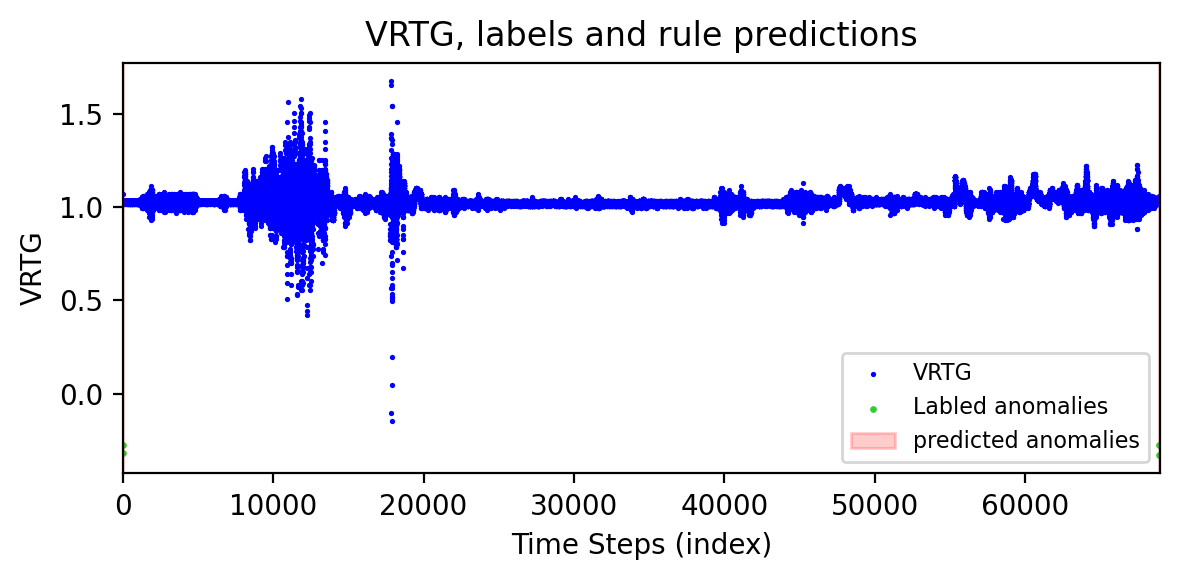

In [61]:
# 查看是否会将 normal 样本误判为 abnormal(jump)

for flight_id in [65]: # [14, 15, 16, 17, 18, 20, 22, 23]
    print(f"========= Flight ID: {flight_id}")

    flight_files_dict = {flight_id: file_name for flight_id, file_name in flight_files}
    file_name = flight_files_dict[flight_id]
    print(file_name)

    data = train_data_aug.copy()
    data = pd.concat([data, test_data.copy()], ignore_index=True)

    flight_data = data[data['flight_id'] == flight_id].reset_index(drop=True)
    vrtg = flight_data['VRTG']

    # segments = detect_jump_segments(vrtg)
    segments = detect_jump_segments_filtered(vrtg)
    if len(segments) > 0:
        print(f"Flight ID: {flight_id}, Jump Segments: {segments}")
        plot_jump(segments, flight_data, min_index=0, max_index=5000000)

        # 借机标数据
        # csv = pd.read_csv(os.path.join("data", file_name))

        # jump_index = []
        # for start, end in segments:
        #     jump_index.extend(range(start, end + 1))

        # csv.loc[csv['index'].isin(jump_index), ['status', 'type']] = ['abnormal', 'jump']

        # csv.to_csv(os.path.join("data", file_name), index=False)
        # print(f"-- Jump Segments Updated in CSV")

    else:
        print(f"Flight ID: {flight_id}, No Jump Segments Detected")
        # plot_jump([], flight_data, min_index=0, max_index=5000000)
        # 仅绘制正常数据

In [60]:
flight_id = 65

flight_data = data[data['flight_id'] == flight_id].reset_index(drop=True)
flight_data

,VRTG,status,flight_id,index,VRTG_diff1,VRTG_diff2,VRTG_median,VRTG_std,VRTG_diff_median,VRTG_diff_10
0,1.023,normal,65,0,0.000,0.000,1.023,0.000000,0.000,1.023
1,1.035,normal,65,1,0.012,0.000,1.029,0.008485,0.006,1.035
2,1.035,normal,65,2,0.000,0.012,1.035,0.006928,0.000,1.035
3,1.023,normal,65,3,-0.012,-0.012,1.029,0.006928,-0.006,1.023
4,1.023,normal,65,4,0.000,-0.012,1.023,0.006573,0.000,1.023
...,...,...,...,...,...,...,...,...,...,...
68955,1.035,normal,65,68955,0.000,0.012,1.023,0.191339,0.012,0.000
68956,1.023,normal,65,68956,-0.012,-0.012,1.023,0.191320,0.000,0.000
68957,1.035,normal,65,68957,0.012,0.000,1.023,0.191320,0.012,0.012
68958,1.035,normal,65,68958,0.000,0.012,1.023,0.191320,0.012,0.000


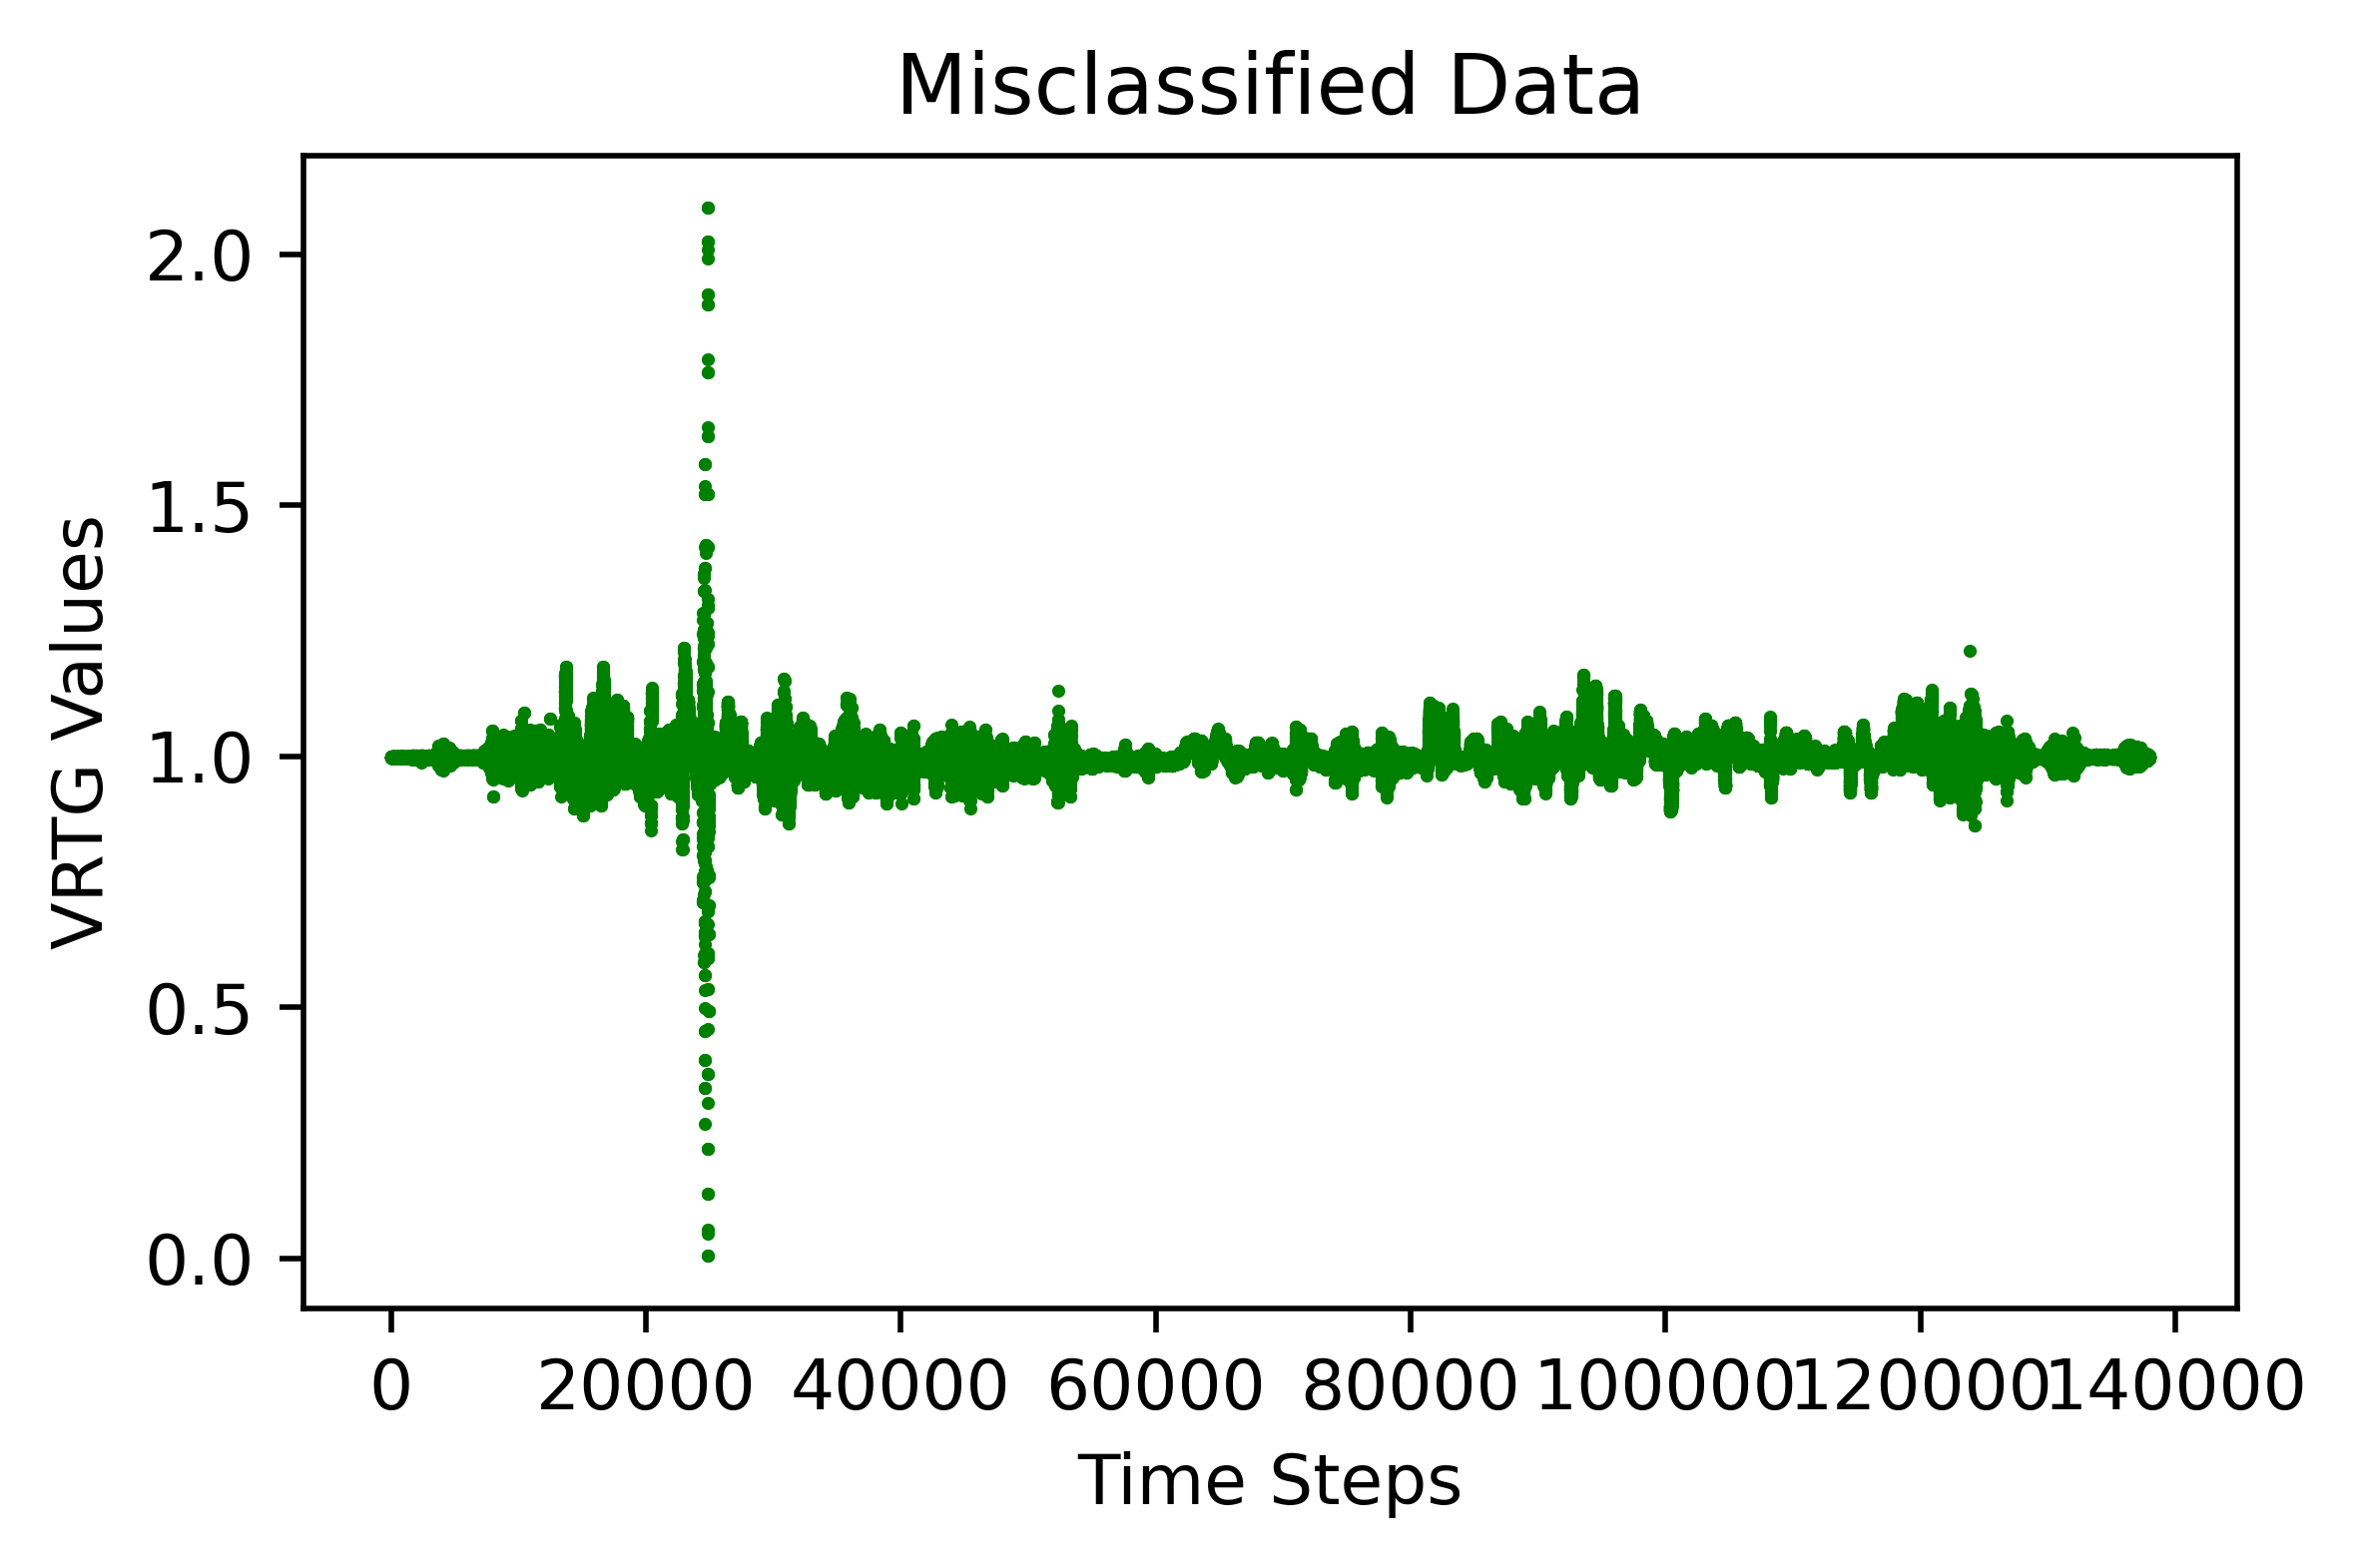

In [59]:
data = test_data.copy()
flight_id = 35

flight_data = data[data['flight_id'] == flight_id].reset_index(drop=True)
vrtg = flight_data['VRTG']

segments = detect_jump_segments(vrtg)

plot_jump(segments, flight_data, min_index=0, max_index=5000000)


In [48]:
flight_id = 15

# 2.选择融合logits的分类阈值

# 3.测试效果

In [36]:
def predict_full_sequence(model, sequence, window_size, stride, num_classes, device):
    """
    对一条完整的序列进行滑动窗口预测，并通过 soft voting 合并结果。

    参数：
    - model: 已训练的模型
    - sequence: numpy array (T, D)，完整飞行序列
    - window_size: int，一侧窗口大小（总长度为 2*window+1）
    - stride: int，滑动步长
    - num_classes: 分类数
    - device: 'cpu' or 'cuda'

    返回：
    - pred_labels: numpy array, shape = (T,)
    """
    model.eval()
    model.to(device)

    seq_len = sequence.shape[0]
    input_dim = sequence.shape[1]
    total_len = 2 * window_size + 1

    # sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, D)
    if isinstance(sequence, np.ndarray):
        sequence_tensor = torch.tensor(sequence, dtype=torch.float32)
    else:
        sequence_tensor = sequence.float()

    sequence_tensor = sequence_tensor.unsqueeze(0).to(device)  # (1, T, D)

    logits_sum = torch.zeros(seq_len, num_classes).to(device)
    count = torch.zeros(seq_len).to(device)

    with torch.no_grad():
        for start in range(0, seq_len - total_len + 1, stride):
            end = start + total_len
            window_input = sequence_tensor[:, start:end, :]  # shape: (1, window_len, D)
            logits = model(window_input)                     # (1, window_len, num_classes)
            logits = logits.squeeze(0)                       # (window_len, num_classes)

            logits_sum[start:end] += logits
            count[start:end] += 1

    count = count.clamp(min=1.0)  # 防止除以0
    avg_logits = logits_sum / count.unsqueeze(1)  # shape: (seq_len, num_classes)
    pred_labels = torch.argmax(avg_logits, dim=1)


    return pred_labels.cpu().numpy(), avg_logits.cpu().numpy()

In [ ]:
def test_single(test_data, flight_id):
    """
    对单条航段进行预测
    参数：
    - test_data: 测试数据集
    - flight_id: 指定航段 ID, 从 test_flight_ids 中选取
    返回：
    - pred: 预测标签序列
    - true: 真实标签序列
    """

    flight_data = test_data[test_data['flight_id'] == flight_id].reset_index(drop=True)

    data = flight_data.drop(columns=['status', 'flight_id', 'index']).values
    true = (flight_data['status'] == 'abnormal').astype(int).values

    # 将数据转换为 numpy 数组
    flight_data_np = np.array(data, dtype=np.float32)
    # 将数据转换为 torch tensor
    flight_data_tensor = torch.tensor(flight_data_np, dtype=torch.float32)

    sequence = flight_data_tensor  # shape = (T, D)

    pred, logits = predict_full_sequence(
        model=model,
        sequence=sequence,
        window_size=window_size,
        stride=stride,
        num_classes=num_classes,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    print("预测标签序列 shape:", pred.shape)
    print("check: ", pred.shape==true.shape)

    return pred, true, flight_data

In [24]:
def plot_miscls_points(mismatches, flight_data, min_index, max_index):
    # 绘制时间序列数据
    flight_data = flight_data.iloc[min_index:max_index]  # 仅绘制指定范围内的数据

    vrtg_data = flight_data[['VRTG', 'status']].copy()

    # 根据 status 标记 normal 和 abnormal 点
    normal_points = vrtg_data[vrtg_data['status'] == 'normal']
    print("normal_points: ", len(normal_points))
    abnormal_points = vrtg_data[vrtg_data['status'] != 'normal']
    # print("abnormal_points: ", abnormal_points)


    plt.figure(figsize=(5, 3))
    # 标记 normal 点（绿色圆点）
    plt.scatter(normal_points.index, normal_points['VRTG'], color='green', s=0.8, label='normal')
    # 标记 abnormal 点（蓝色正方形）
    plt.scatter(abnormal_points.index, abnormal_points['VRTG'], color='blue', s=0.8, label='abnormal/attention')

    # 标记误判点（红色 'x'）
    # 确保 mismatches 的索引在 vrtg_data 的范围内
    valid_mismatches = [point for point in mismatches if point >= min_index and point < max_index]
    plt.scatter(valid_mismatches, vrtg_data.loc[valid_mismatches, 'VRTG'], color='red', marker='x', s=0.2, label='misclassified')

    # 设置标题和标签
    plt.title(f"Misclassified Data")
    plt.xlabel("Time Steps")
    plt.ylabel("VRTG Values")
    plt.legend()
    plt.show()
    plt.rcParams['figure.dpi'] = 500  # 设置图像分辨率


In [11]:
test_flight_ids

[9,
 10,
 11,
 12,
 13,
 21,
 22,
 23,
 24,
 26,
 37,
 38,
 39,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 134]

In [12]:
train_flight_ids

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 25,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 133,
 135]

## 单条测试航段

In [19]:
# pred, true, flight_data = test_single(test_data, flight_id=132)
pred, true, flight_data = test_single(train_data_aug, flight_id=14)

pred = np.array(pred)
true = np.array(true)
mismatches = np.where(pred != true)[0]  # 返回的是索引数组
mismatches = mismatches.tolist()
len(mismatches)


/var/folders/d7/d2wfztyn1t377jq06lpgq0_40000gn/T/ipykernel_23365/3337392911.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, D)


预测标签序列 shape: (103040,)
check:  True


104

In [20]:
len(mismatches)
# len(true)

104

normal_points:  99899


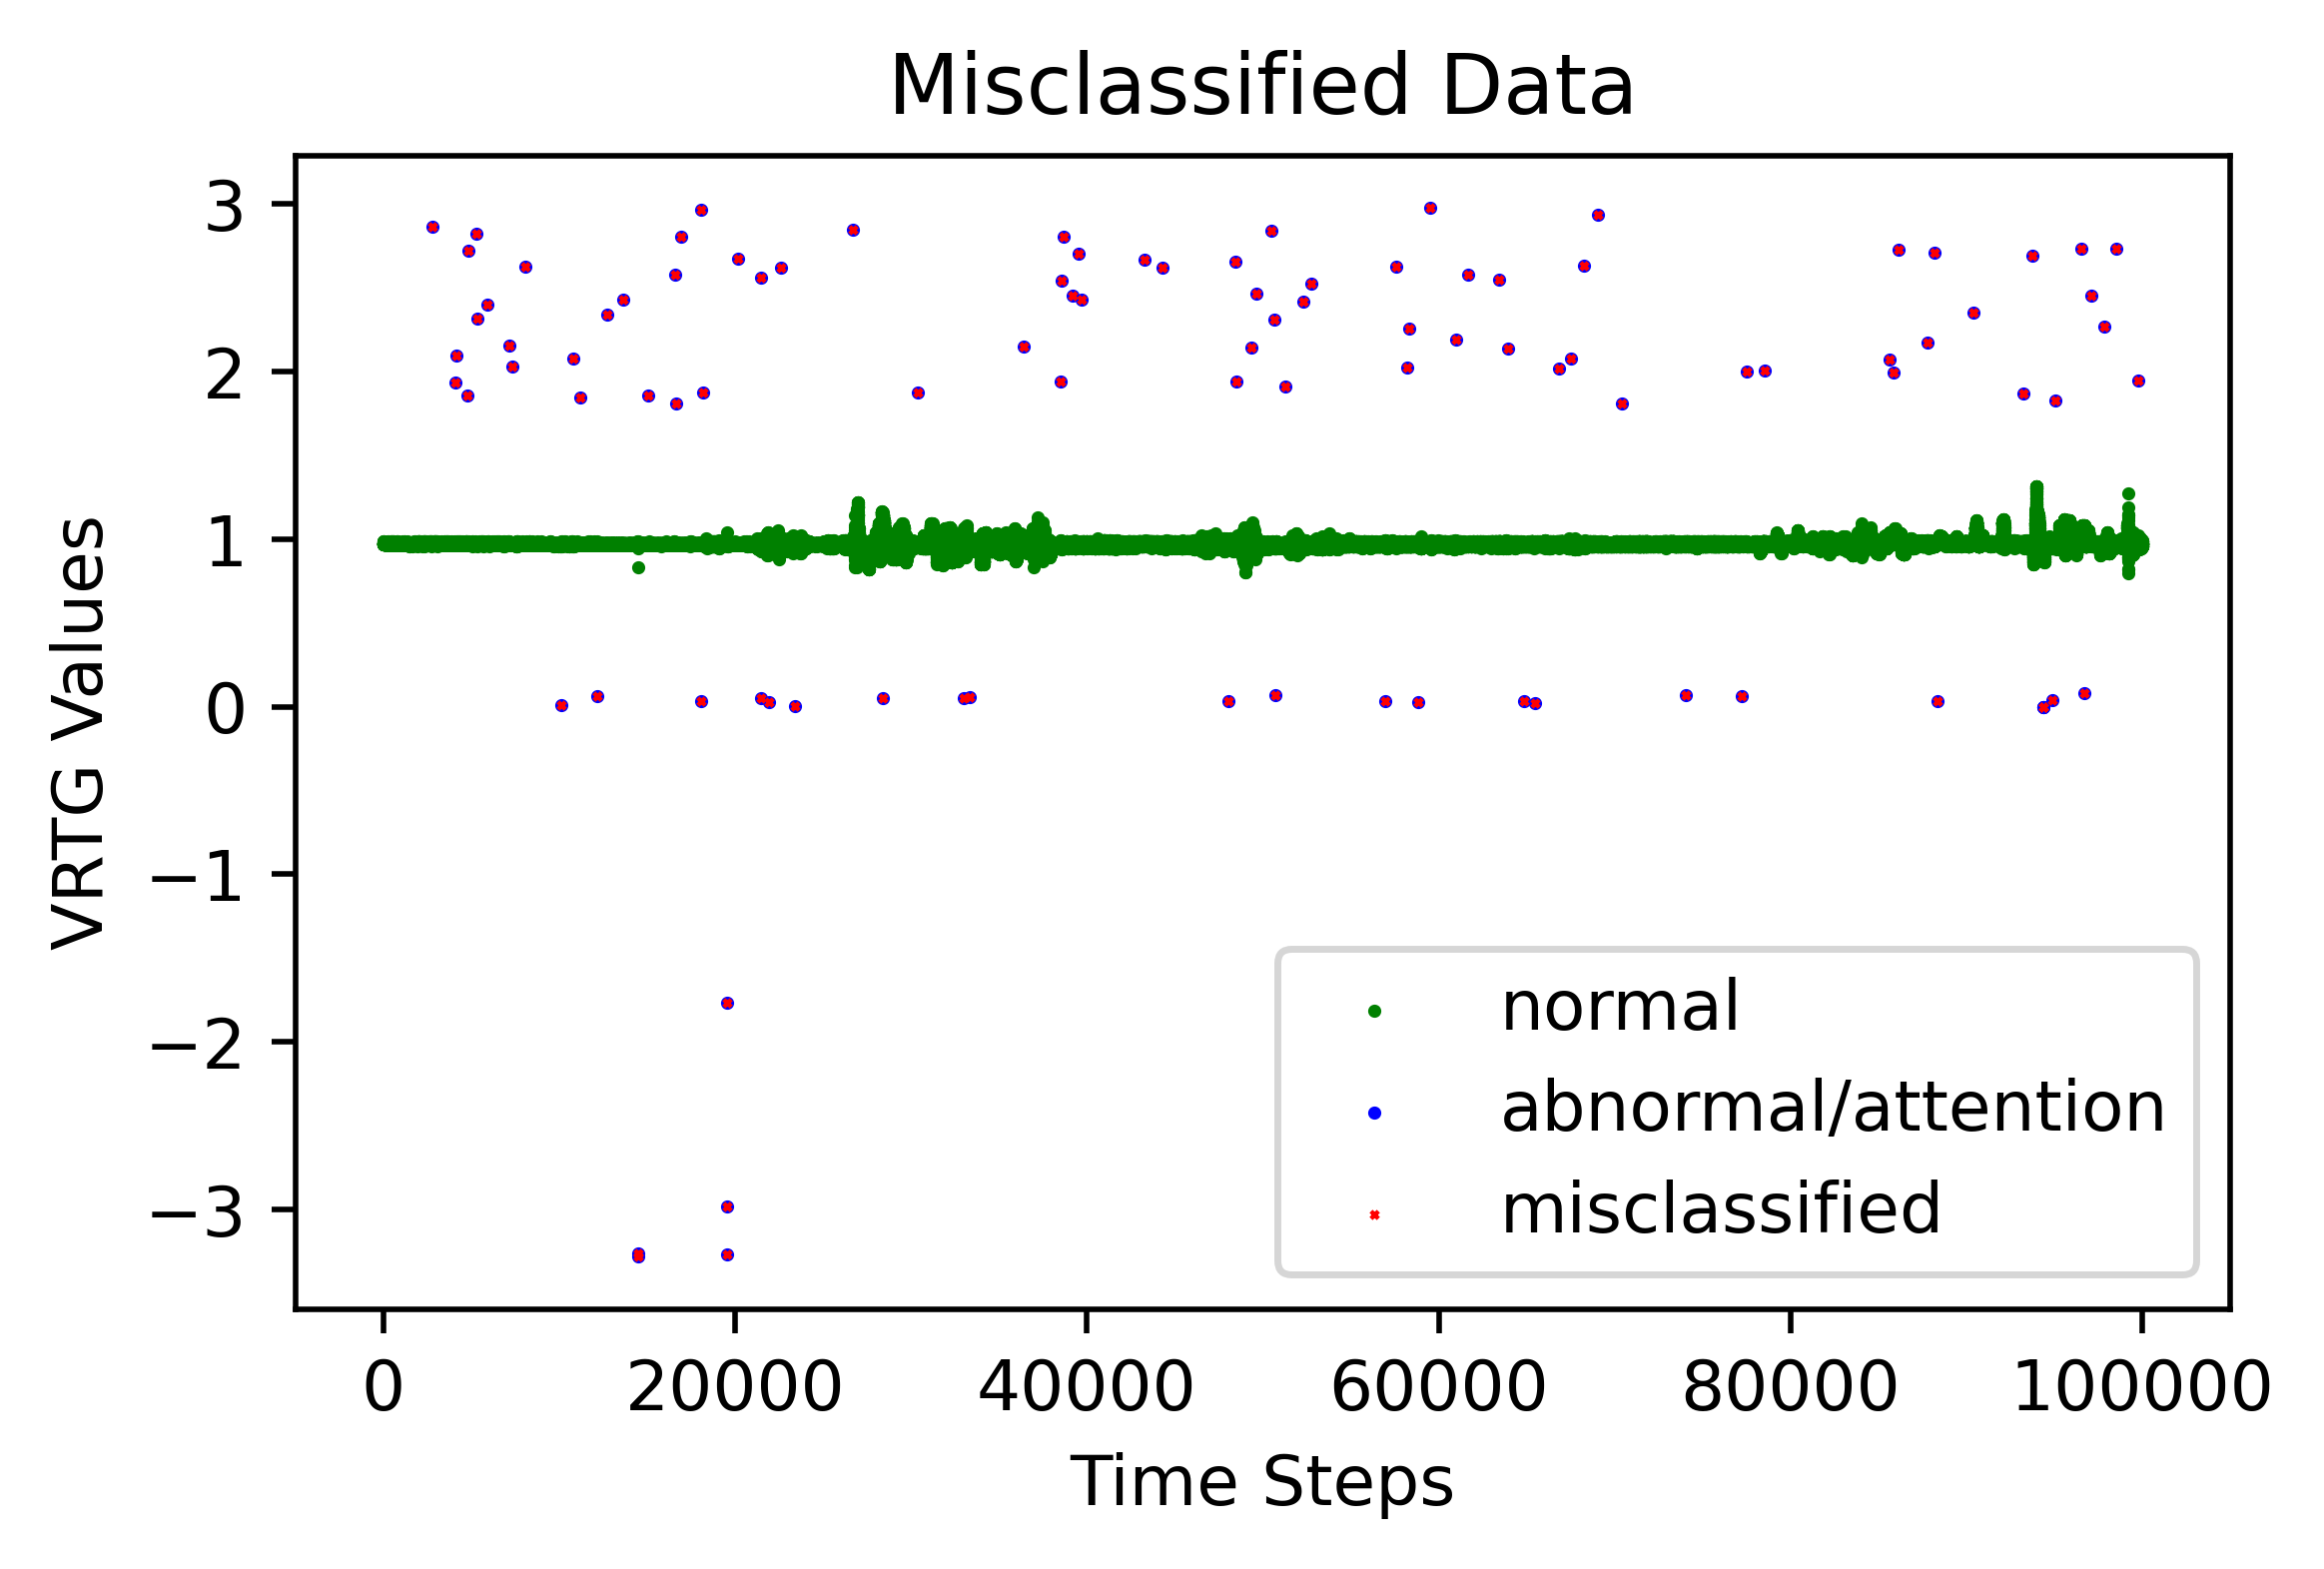

In [25]:
plot_miscls_points(mismatches, flight_data, min_index=0, max_index=100000)

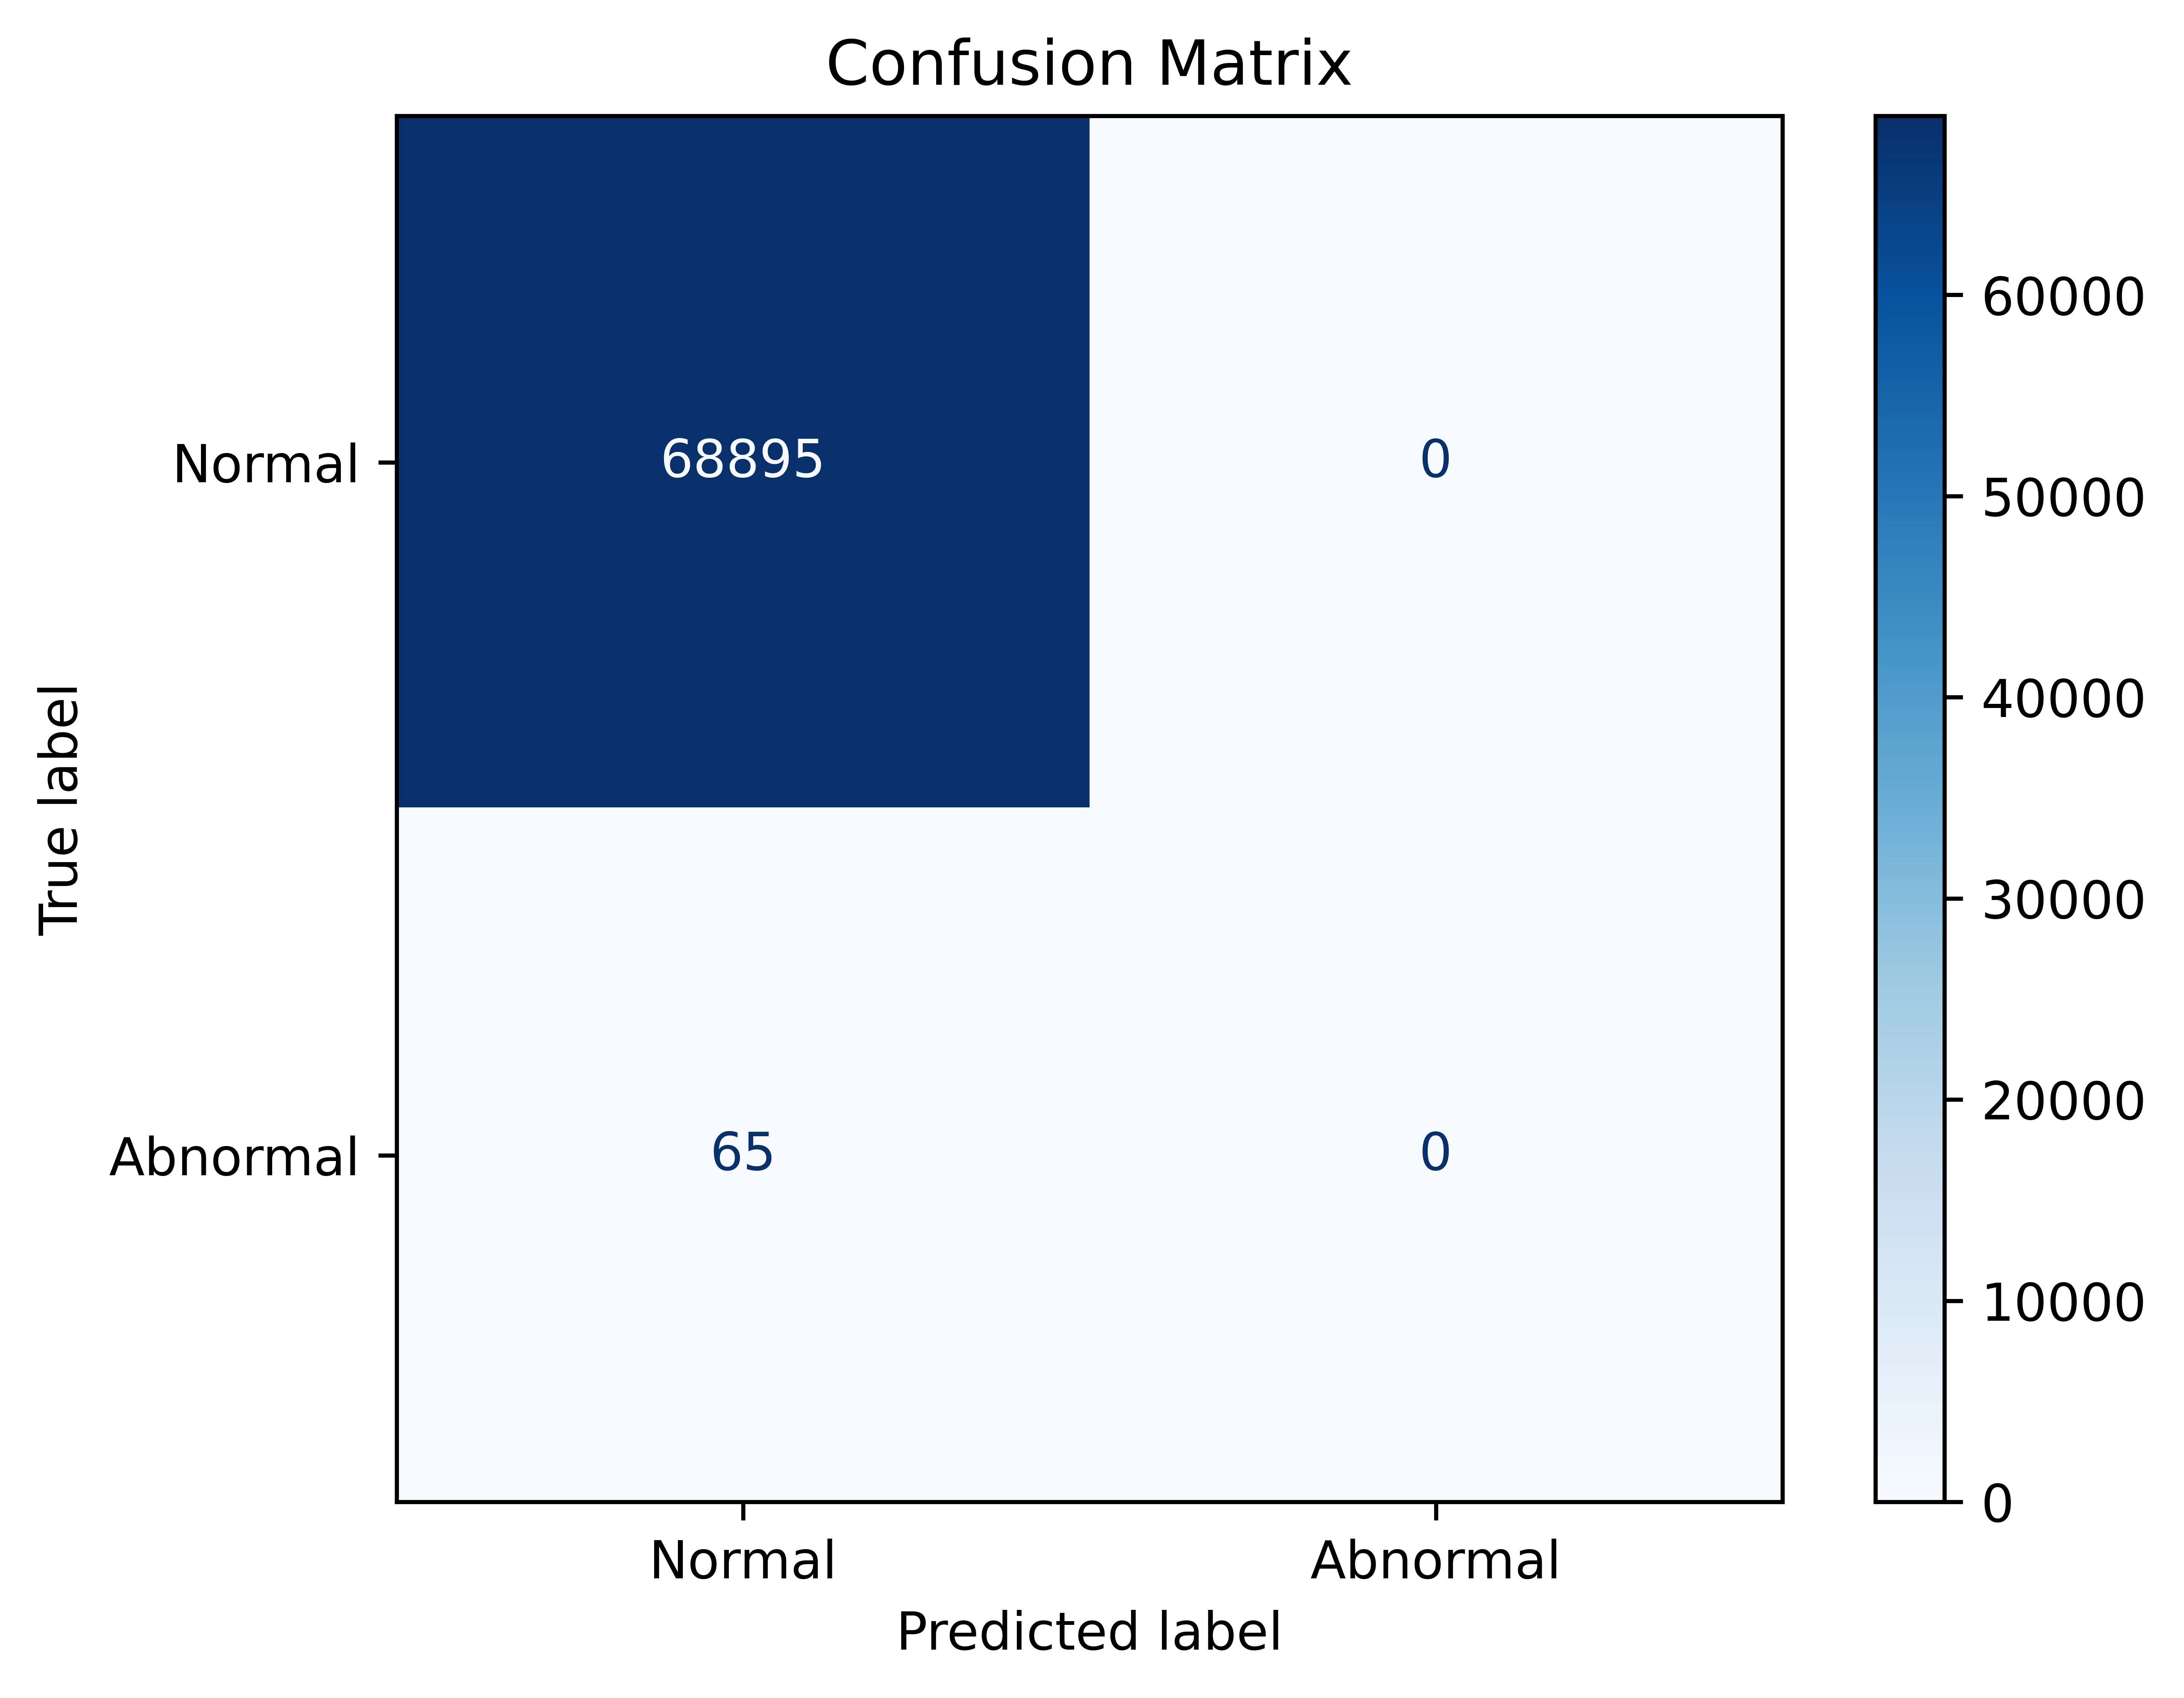


📋 Classification Report:
              precision    recall  f1-score   support

      Normal     0.9991    1.0000    0.9995     68895
    Abnormal     0.0000    0.0000    0.0000        65

    accuracy                         0.9991     68960
   macro avg     0.4995    0.5000    0.4998     68960
weighted avg     0.9981    0.9991    0.9986     68960

✅ Accuracy: 0.9991
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Unique labels: [0 1]
🔥 AUC (ROC): 0.5000


/Users/kiki/miniforge3/envs/torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/kiki/miniforge3/envs/torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/kiki/miniforge3/envs/torch/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result)

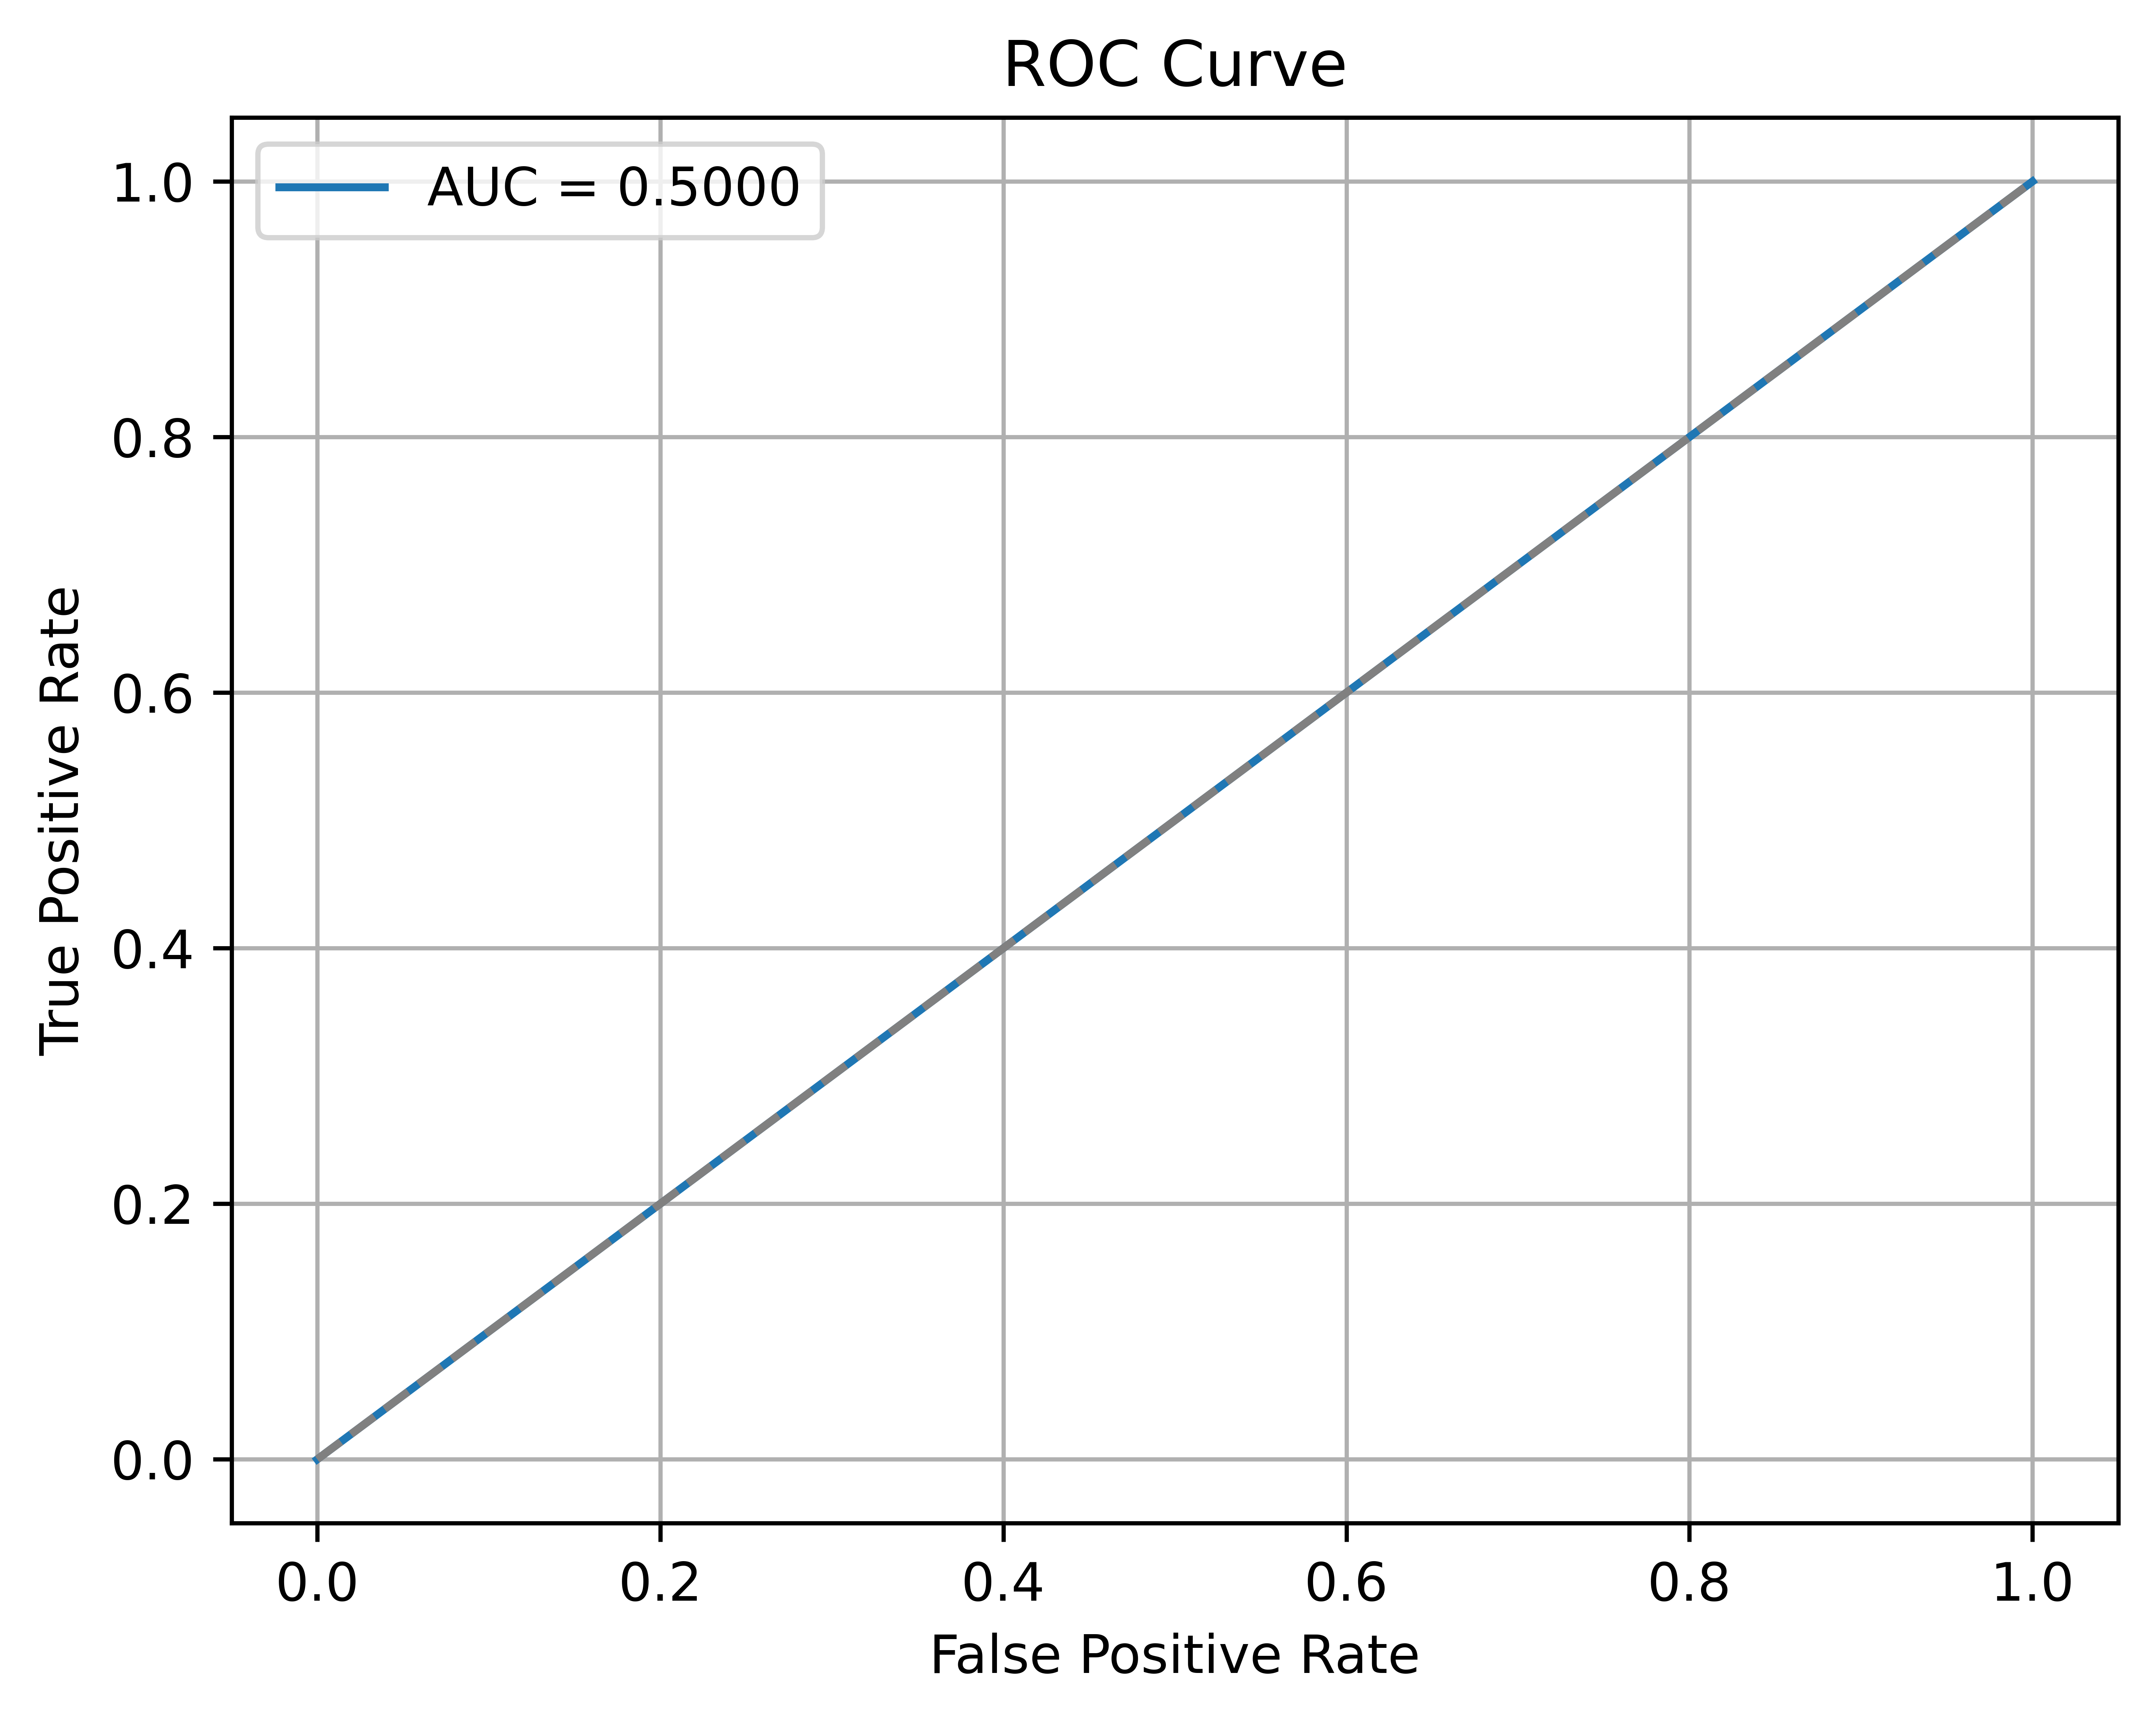

In [16]:
class_names = ['Normal', 'Abnormal']  # 或根据你的标签映射自定义

evaluate_classification(pred, true, class_names=class_names)


## 2.1训练集总体效果

In [ ]:
def test_overall_metrics(test_data):
    test_ids = test_data['flight_id'].unique()
    all_preds = []
    all_trues = []
    all_logits = []
    all_flight_ids = []
    all_indices = []
    
    for flight_id in tqdm(test_ids, desc="Testing", leave=False):
        flight_data = test_data[test_data['flight_id'] == flight_id]
        
        data = flight_data.drop(columns=['status', 'flight_id', 'index']).values
        
        true = (flight_data['status'] == 'abnormal').astype(int).values
        all_trues.extend(true)

        # 将数据转换为 numpy 数组
        flight_data_np = np.array(data, dtype=np.float32)
        # 将数据转换为 torch tensor
        flight_data_tensor = torch.tensor(flight_data_np, dtype=torch.float32)

        sequence = flight_data_tensor  # shape = (T, D)

        pred, logits = predict_full_sequence(
            model=model,
            sequence=sequence,
            window_size=window_size,
            stride=stride,
            num_classes=num_classes,
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
        )
        all_preds.extend(pred)
        all_logits.extend(logits)
        # print("check: ", pred.shape==true.shape)

    return np.array(all_preds), np.array(all_trues), np.array(all_logits)

In [38]:
all_preds, all_trues, all_logits = test_overall_metrics(train_data_aug)

Testing:   1%|          | 1/102 [00:48<1:21:11, 48.23s/it]

check:  True


Testing:   2%|▏         | 2/102 [01:22<1:06:21, 39.82s/it]

check:  True


Testing:   3%|▎         | 3/102 [03:18<2:03:19, 74.74s/it]

...

Testing:  98%|█████████▊| 100/102 [1:14:05<01:29, 44.52s/it]

check:  True


Testing:  99%|█████████▉| 101/102 [1:14:34<00:39, 39.80s/it]

check:  True


check:  True


In [46]:
all_preds.shape

(8923328,)

In [45]:
all_logits

array([[ 6.754375 , -7.0990973],
       [ 7.3232574, -7.6471214],
       [ 7.711007 , -7.9928694],
       ...,
       [ 0.       ,  0.       ],
       [ 0.       ,  0.       ],
       [ 0.       ,  0.       ]], dtype=float32)

## 2.2根据logits看阈值

In [47]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt

def find_best_threshold(all_trues, all_logits, step=0.01, plot=True):
    """
    从预测概率中寻找最佳分类阈值，使 F1 分数最大。
    all_logits 应为 shape (N, 2)，表示两个类别的预测概率。
    
    参数：
    - all_trues: shape (N,) 的真实标签
    - all_logits: shape (N, 2) 的预测概率
    - step: 阈值步长
    - plot: 是否绘图（F1, Precision, Recall vs 阈值）

    返回：
    - best_thresh: float
    - best_f1: float
    """
    # 取类别1（正类）的概率
    probs = all_logits[:, 1]

    best_thresh = 0.0
    best_f1 = 0.0
    thresholds = np.arange(0.0, 1.0 + step, step)

    f1_scores = []
    precision_scores = []
    recall_scores = []

    for thresh in tqdm(thresholds, desc="Searching threshold"):
        preds = (probs >= thresh).astype(int)
        f1 = f1_score(all_trues, preds)
        precision = precision_score(all_trues, preds, zero_division=0)
        recall = recall_score(all_trues, preds, zero_division=0)

        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

        print(f"Threshold: {thresh:.2f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(thresholds, f1_scores, label='F1 Score', marker='o')
        plt.plot(thresholds, precision_scores, label='Precision', linestyle='--')
        plt.plot(thresholds, recall_scores, label='Recall', linestyle='-.')
        plt.axvline(x=best_thresh, color='red', linestyle=':', label=f'Best Threshold = {best_thresh:.2f}')
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.title("Threshold Search: F1 / Precision / Recall")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return best_thresh, best_f1


In [ ]:
import torch

all_logits_tensor = torch.tensor(all_logits)  # Convert numpy array to torch tensor

probs = F.softmax(all_logits_tensor, dim=-1).detach().cpu().numpy()
probs = probs.reshape(-1, 2)        # (N, 2)
probs.shape


(8923328, 2)

In [53]:
probs

array([[9.9999905e-01, 9.6274937e-07],
       [9.9999964e-01, 3.1509893e-07],
       [9.9999988e-01, 1.5131886e-07],
       ...,
       [5.0000000e-01, 5.0000000e-01],
       [5.0000000e-01, 5.0000000e-01],
       [5.0000000e-01, 5.0000000e-01]], dtype=float32)

In [ ]:
best_thresh, best_f1 = find_best_threshold(all_trues, probs, step=0.01)
print(f"\nBest threshold: {best_thresh:.3f}, Best F1: {best_f1:.4f}")
normal_jump


Searching threshold:   1%|          | 1/101 [00:06<10:39,  6.40s/it]

Threshold: 0.00 | F1: 0.1318 | Precision: 0.0705 | Recall: 1.0000


Searching threshold:   2%|▏         | 2/101 [00:12<10:22,  6.29s/it]

Threshold: 0.01 | F1: 0.9610 | Precision: 0.9810 | Recall: 0.9418


Searching threshold:   3%|▎         | 3/101 [00:18<10:11,  6.24s/it]

...

Threshold: 0.04 | F1: 0.9616 | Precision: 0.9828 | Recall: 0.9413


Searching threshold:   6%|▌         | 6/101 [00:38<10:08,  6.41s/it]

Threshold: 0.05 | F1: 0.9616 | Precision: 0.9829 | Recall: 0.9412


Searching threshold:   7%|▋         | 7/101 [00:44<09:58,  6.37s/it]

Threshold: 0.06 | F1: 0.9616 | Precision: 0.9831 | Recall: 0.9411


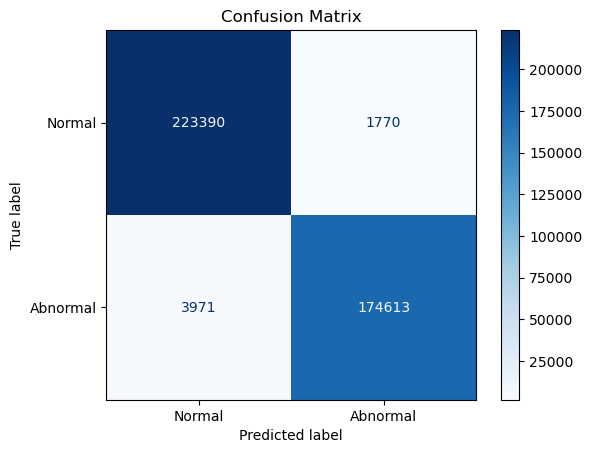


📋 Classification Report:
              precision    recall  f1-score   support

      Normal     0.9825    0.9921    0.9873    225160
    Abnormal     0.9900    0.9778    0.9838    178584

    accuracy                         0.9858    403744
   macro avg     0.9862    0.9850    0.9856    403744
weighted avg     0.9858    0.9858    0.9858    403744

✅ Accuracy: 0.9858
Precision: 0.9900
Recall: 0.9778
F1 Score: 0.9838
Unique labels: [0 1]
🔥 AUC (ROC): 0.9850


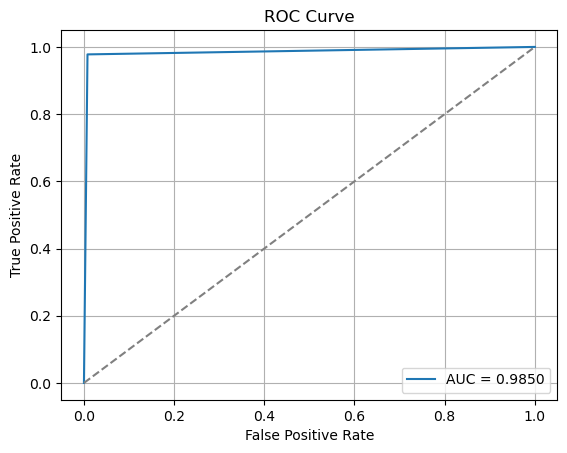

In [84]:
evaluate_classification(all_preds, all_trues, class_names=class_names)


## 红色事件

In [ ]:
def red_pred(model, red_csv, red_preds_path):
    new_data = pd.read_csv(red_csv, usecols=['status', 'VRTG'])
    
    # 必须先处理一下数据，否则会报错
    new_data = new_data[pd.to_numeric(new_data['VRTG'], errors='coerce').notnull()]
    new_data['VRTG'] = pd.to_numeric(new_data['VRTG'])
    new_data.reset_index(drop=True, inplace=True)
    new_data['index'] = new_data.index  # 记录在该航段中的原始索引
    true = (new_data['status'] == 'abnormal').astype(int).values

    new_data = compute_features_red(new_data, rolling_window_size)
    
    # 提取特征
    X_new = new_data[features].values

    # 将数据转换为 numpy 数组
    flight_data_np = np.array(X_new, dtype=np.float32)
    # 将数据转换为 torch tensor
    flight_data_tensor = torch.tensor(flight_data_np, dtype=torch.float32)

    sequence = flight_data_tensor  # shape = (T, D)

    pred, logits = predict_full_sequence(
        model=model,
        sequence=sequence,
        window_size=window_size,
        stride=stride,
        num_classes=num_classes,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    print("预测标签序列 shape:", pred.shape)
    print("check: ", pred.shape==true.shape)
    
    pd.DataFrame(pred).to_csv(red_preds_path, index=False)

    return pred, true, new_data

In [ ]:
def test_single(test_data):
    flight_data = test_data[test_data['flight_id'] == flight_id].reset_index(drop=True)

    data = flight_data.drop(columns=['status', 'flight_id', 'index']).values
    true = (flight_data['status'] == 'abnormal').astype(int).values

    # 将数据转换为 numpy 数组
    flight_data_np = np.array(data, dtype=np.float32)
    # 将数据转换为 torch tensor
    flight_data_tensor = torch.tensor(flight_data_np, dtype=torch.float32)

    sequence = flight_data_tensor  # shape = (T, D)

    pred, logits = predict_full_sequence(
        model=model,
        sequence=sequence,
        window_size=window_size,
        stride=stride,
        num_classes=num_classes,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )

    print("预测标签序列 shape:", pred.shape)
    print("check: ", pred.shape==true.shape)

    return pred, true

In [195]:
red_csv = "data/3378421620230812B-5706.csv"
red_preds_path = "test-5706.csv"

pred, true, new_data = red_pred(model, red_csv, red_preds_path)

/var/folders/d7/d2wfztyn1t377jq06lpgq0_40000gn/T/ipykernel_47606/3337392911.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, D)


预测标签序列 shape: (97440,)
check:  True


In [197]:
pred = np.array(pred)
true = np.array(true)
mismatches = np.where(pred != true)[0]  # 返回的是索引数组
mismatches = mismatches.tolist()

In [203]:
sum(pred)

97421

In [202]:
true

array([0, 0, 0, ..., 0, 0, 0])

In [200]:
mismatches

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [198]:
new_data

,status,VRTG,index,VRTG_diff1,VRTG_diff2,VRTG_median,VRTG_std,VRTG_diff_median,VRTG_diff_10
0,normal,1.002,0,0.000,0.000,1.002,0.000000,0.000,1.002
1,normal,0.998,1,-0.004,0.000,1.000,0.002828,-0.002,0.998
2,normal,1.002,2,0.004,0.000,1.002,0.002309,0.000,1.002
3,normal,1.002,3,0.000,0.004,1.002,0.002000,0.000,1.002
4,normal,1.000,4,-0.002,-0.002,1.002,0.001789,-0.002,1.000
...,...,...,...,...,...,...,...,...,...
97435,normal,1.005,97435,0.000,0.000,1.005,0.001912,0.000,0.000
97436,normal,1.005,97436,0.000,0.000,1.005,0.001905,0.000,0.000
97437,normal,1.002,97437,-0.003,-0.003,1.005,0.001934,-0.003,-0.003
97438,normal,1.002,97438,0.000,-0.003,1.005,0.001955,-0.003,-0.003


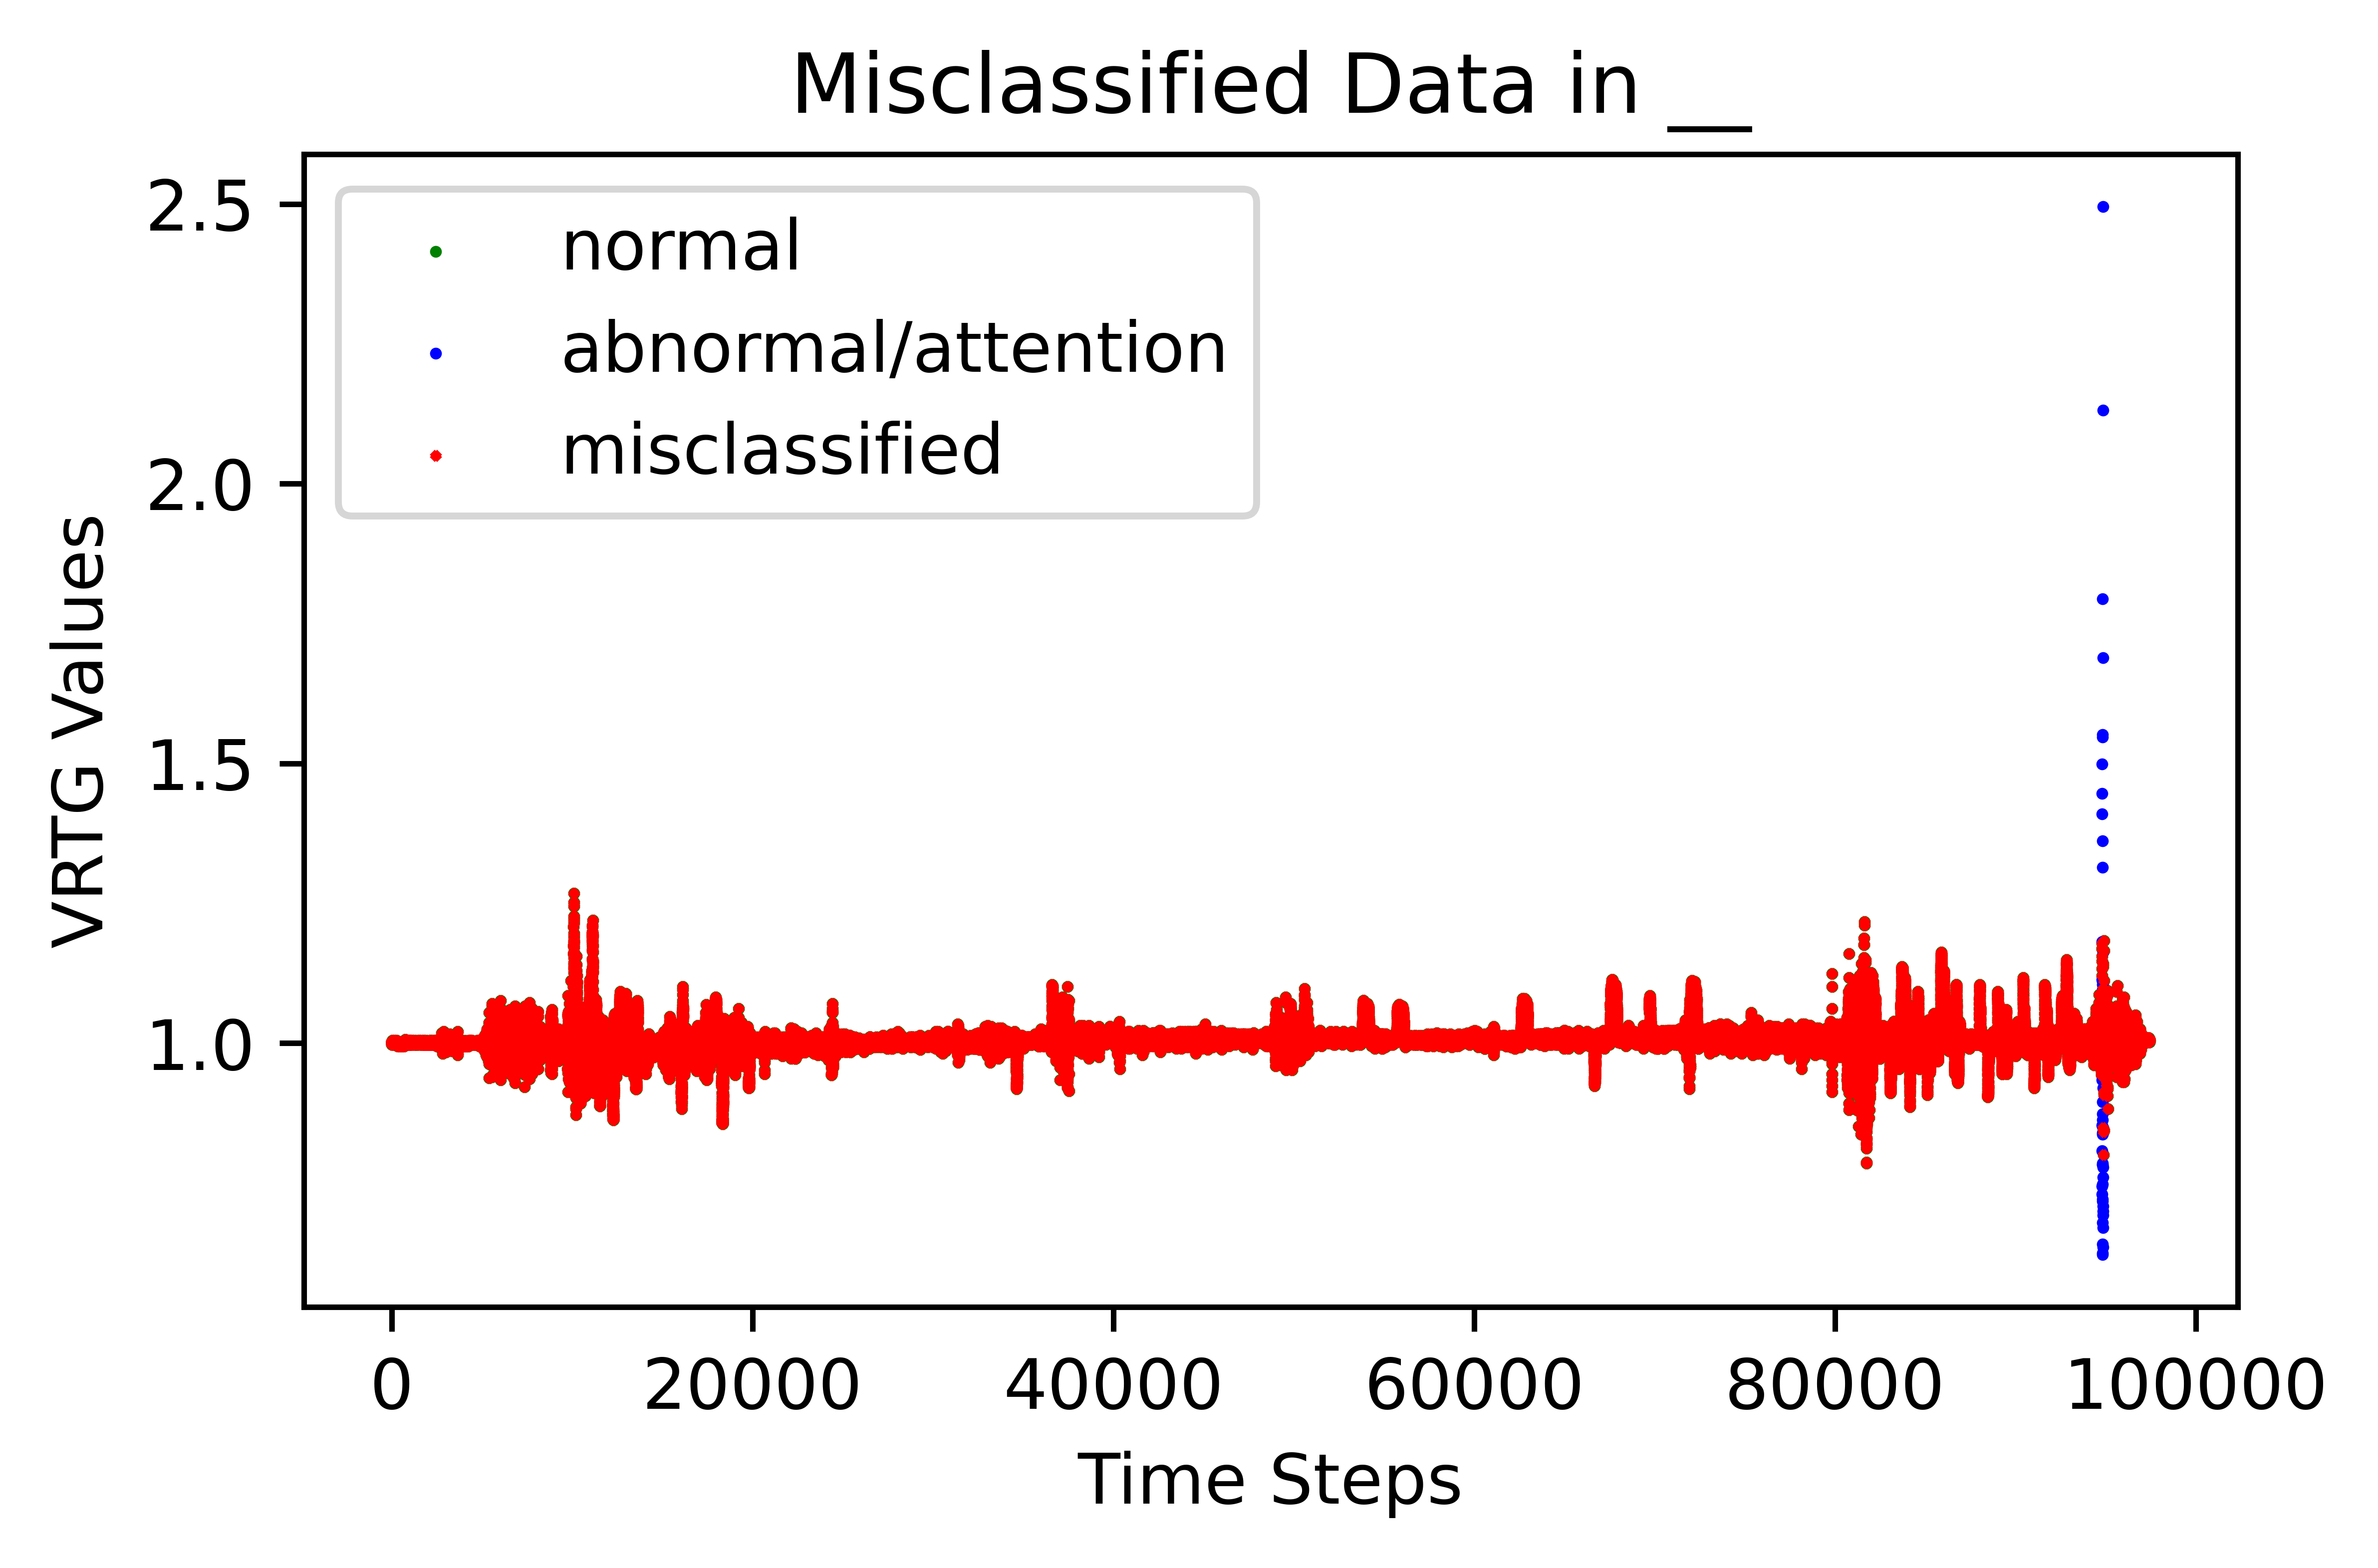

In [205]:
plot_miscls_points(mismatches, new_data, min_index=0, max_index=100000)
